<a href="https://colab.research.google.com/github/ZeroToH3ro/Predictive-Model-Advance/blob/main/Predictive_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import warnings

# Keep notebook output clean.
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.simplefilter("ignore")

import numpy as np

# Suppress NumPy floating-point warnings (e.g., divide-by-zero) that can appear during modeling.
np.seterr(all="ignore")

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from model_utils import FiniteClipper
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


In [2]:
def load_ras_features(ras_path, sheet_name="Sheet1"):
    ras_df = pd.read_excel(ras_path, sheet_name=sheet_name)
    if "Accession number" not in ras_df.columns:
        raise ValueError("Accession number column missing in RAS file.")

    drop_cols = {col for col in ras_df.columns if col.lower() in {"no", "id"}}
    genotype_cols = [col for col in ras_df.columns if col.lower() == "genotype"]

    features = pd.DataFrame({"Accession number": ras_df["Accession number"]})

    numeric_cols = ras_df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in drop_cols and col != "Accession number"]
    if numeric_cols:
        features = pd.concat([features, ras_df[numeric_cols]], axis=1)

    for gen_col in genotype_cols:
        gen_series = ras_df[gen_col].astype(str).str.strip()
        gen_series = gen_series.replace({"nan": np.nan, "None": np.nan, "": np.nan})
        dummies = pd.get_dummies(gen_series, prefix=gen_col)
        features = pd.concat([features, dummies], axis=1)

    mutation_cols = []
    for col in ras_df.columns:
        if col in drop_cols or col == "Accession number" or col in genotype_cols or col in numeric_cols:
            continue
        col_type = ras_df[col].dtype
        if col_type == object or str(col_type) == "string":
            name = col.lower()
            if any(key in name for key in ["mut", "mutation", "resistance", "ras"]):
                mutation_cols.append(col)

    if mutation_cols:
        import re

        def count_mutations(val):
            if pd.isna(val):
                return 0
            if isinstance(val, (int, float)) and not isinstance(val, bool):
                if np.isnan(val):
                    return 0
                return int(val)
            s = str(val).strip()
            if not s or s.lower() in {"nan", "none", "na"}:
                return 0
            if re.fullmatch(r"[-+]?\d+(\.\d+)?", s):
                return int(float(s))
            s = s.strip("[]()")
            parts = [part for part in re.split(r"[;,\s]+", s) if part]
            return len(parts)

        for col in mutation_cols:
            features[col] = ras_df[col].apply(count_mutations).astype(float)

    return features


def build_target(response_series):
    response_map = {
        "SVR": 0,
        "Non SVR": 1,
    }
    response_series = response_series.astype(str).str.strip()
    y = response_series.map(response_map)
    if y.isna().any():
        bad_values = sorted(response_series[y.isna()].unique())
        raise ValueError(f"Unmapped Respond values: {bad_values}")
    return y.values


In [3]:
def build_feature_matrix(ras_path, ras_sheet="Sheet1"):
    ras_raw = pd.read_excel(ras_path, sheet_name=ras_sheet)
    ras_raw["Accession number"] = ras_raw["Accession number"].astype(str).str.strip()

    if "Respond" not in ras_raw.columns:
        raise ValueError("Respond column missing in RAS file; cannot build targets.")

    ras_features = load_ras_features(ras_path, sheet_name=ras_sheet)
    ras_features["Accession number"] = ras_features["Accession number"].astype(str).str.strip()

    ras_features = ras_features.set_index("Accession number").loc[ras_raw["Accession number"]].reset_index()

    ras_cols = [c for c in ras_features.columns if c != "Accession number"]
    X = ras_features[ras_cols].to_numpy().astype(float)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    y = build_target(ras_raw["Respond"])
    feature_names = ras_cols
    return X, y, ras_raw, ras_features, feature_names


In [4]:
def optimize_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    finite_mask = np.isfinite(thresholds)
    if finite_mask.any():
        thresholds = thresholds[finite_mask]
        fpr = fpr[finite_mask]
        tpr = tpr[finite_mask]
    else:
        return 0.5, fpr, tpr

    youden = tpr - fpr
    best_idx = np.argmax(youden)
    return thresholds[best_idx], fpr, tpr


def plot_roc_curve(fpr, tpr, auc_score, label):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=3, label=f"{label} (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def bootstrap_sensitivity_analysis(
    results,
    n_bootstraps=1000,
    random_state=42,
    label="",
    save_path=None,
):
    """
    Bootstrap sensitivity analysis for all trained models.

    Resamples the test set `n_bootstraps` times and computes
    Accuracy, Precision, Recall, F1, and AUC on each resample.
    Reports mean, std, and 95 % confidence intervals.
    Saves an Excel summary and prints results.
    """
    import os
    import numpy as np
    import pandas as pd
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
    )

    model_results = results.get("models", {})
    X_test = results["X_test"]
    y_test = results["y_test"]
    out_path = save_path or results.get("save_path", os.getcwd())
    os.makedirs(out_path, exist_ok=True)

    rng = np.random.RandomState(random_state)
    n_test = len(y_test)

    summary_rows = []

    for model_name, info in model_results.items():
        model = (info or {}).get("model")
        if model is None:
            print(f"{model_name}: model unavailable; skipping bootstrap.")
            continue

        metrics = {
            "Accuracy": [],
            "Precision": [],
            "Recall": [],
            "F1_Score": [],
            "AUC_Score": [],
        }

        skipped = 0
        for _ in range(n_bootstraps):
            idx = rng.choice(n_test, size=n_test, replace=True)
            X_boot = X_test[idx]
            y_boot = y_test[idx]

            # Need both classes for AUC
            if len(np.unique(y_boot)) < 2:
                skipped += 1
                continue

            try:
                y_proba = model.predict_proba(X_boot)[:, 1]
            except Exception:
                skipped += 1
                continue

            threshold, _, _ = optimize_threshold(y_boot, y_proba)
            y_pred = (y_proba >= threshold).astype(int)

            metrics["Accuracy"].append(accuracy_score(y_boot, y_pred))
            metrics["Precision"].append(precision_score(y_boot, y_pred, zero_division=0))
            metrics["Recall"].append(recall_score(y_boot, y_pred, zero_division=0))
            metrics["F1_Score"].append(f1_score(y_boot, y_pred, zero_division=0))
            metrics["AUC_Score"].append(roc_auc_score(y_boot, y_proba))

        if not metrics["Accuracy"]:
            print(f"{model_name}: all bootstrap iterations failed.")
            continue

        print(f"\n=== Bootstrap Sensitivity Analysis: {model_name} ===")
        print(f"    Iterations: {n_bootstraps}  |  Skipped: {skipped}")
        for m_name, values in metrics.items():
            arr = np.array(values)
            mean = np.mean(arr)
            std  = np.std(arr)
            lo   = np.percentile(arr, 2.5)
            hi   = np.percentile(arr, 97.5)
            print(f"    {m_name:12s}  mean={mean:.4f}  std={std:.4f}  "
                  f"95% CI=[{lo:.4f}, {hi:.4f}]")
            summary_rows.append({
                "Model": model_name,
                "Metric": m_name,
                "Mean": round(mean, 4),
                "Std": round(std, 4),
                "CI_Lower_2.5%": round(lo, 4),
                "CI_Upper_97.5%": round(hi, 4),
                "N_Bootstraps": n_bootstraps - skipped,
            })

    if summary_rows:
        df = pd.DataFrame(summary_rows)
        xlsx = os.path.join(out_path, f"bootstrap_sensitivity_{label}.xlsx")
        df.to_excel(xlsx, index=False)
        print(f"\nBootstrap results saved to {xlsx}")
    else:
        print("\nNo bootstrap results to save.")


In [6]:
def train_and_evaluate_models(X, y, seq_df, feature_names, label="", save_path=None, include_xgboost=True):
    try:
        from xgboost import XGBClassifier
        has_xgb = True
    except ImportError:
        has_xgb = False
        if include_xgboost:
            print("xgboost not installed; skipping XGBoost model.")

    if save_path is None:
        save_path = os.path.join(os.getcwd(), "ml_results")
    os.makedirs(save_path, exist_ok=True)

    print(f"Label: {label}")
    print("Class distribution:", pd.Series(y).value_counts().to_dict())

    indices = np.arange(len(y))
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, indices, test_size=0.4, random_state=42, stratify=y
    )

    base_steps = [
        ("var", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("finite", FiniteClipper()),
    ]

    models = [
        {
            "name": "SVM",
            "estimator": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
            "param_grid": {
                "model__C": [0.1, 1, 10],
                "model__gamma": ["scale", 0.1, 0.01],
            },
            "extra_steps": [("pca", PCA(n_components=0.95, svd_solver="full", random_state=42))],
        },
        {
            "name": "Elastic Net",
            "estimator": LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=5000,
                class_weight="balanced",
            ),
            "param_grid": {
                "model__C": [0.01, 0.1, 1, 10],
                "model__l1_ratio": [0.1, 0.5, 0.9],
            },
        },
        {
            "name": "Random Forest",
            "estimator": RandomForestClassifier(random_state=42, class_weight="balanced"),
            "param_grid": {
                "model__n_estimators": [300, 500],
                "model__max_depth": [None, 20],
                "model__min_samples_leaf": [1, 2],
            },
        },
        {
            "name": "GBM",
            "estimator": GradientBoostingClassifier(random_state=42),
            "param_grid": {
                "model__n_estimators": [200, 400],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [2, 3],
            },
        },
        {
            "name": "Decision Tree",
            "estimator": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
            "param_grid": {
                "model__max_depth": [3, 5, None],
                "model__min_samples_leaf": [1, 2],
            },
        },
        {
            "name": "FDA",
            "estimator": QuadraticDiscriminantAnalysis(),
            "param_grid": {
                "model__reg_param": [0.0, 0.1, 0.5],
            },
        },
        {
            "name": "KNN",
            "estimator": KNeighborsClassifier(),
            "param_grid": {
                "model__n_neighbors": [3, 5, 7],
                "model__weights": ["uniform", "distance"],
            },
        },
        {
            "name": "Logistic Regression",
            "estimator": LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42),
            "param_grid": {
                "model__C": [0.01, 0.1, 1, 10],
            },
        },
        {
            "name": "Naive Bayesian",
            "estimator": GaussianNB(),
            "param_grid": {
                "model__var_smoothing": [1e-9, 1e-8, 1e-7],
            },
        },
        {
            "name": "Neural Network",
            "estimator": MLPClassifier(max_iter=1000, random_state=42),
            "param_grid": {
                "model__hidden_layer_sizes": [(50,), (100,)],
                "model__alpha": [0.0001, 0.001, 0.01],
            },
        },
        {
            "name": "Voting Classifier",
            "estimator": VotingClassifier(
                estimators=[
                    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)),
                    ("rf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
                    ("gbm", GradientBoostingClassifier(n_estimators=100, random_state=42))
                ],
                voting="soft"
            ),
            "param_grid": {},
        },
        {
            "name": "Stacking Classifier",
            "estimator": StackingClassifier(
                estimators=[
                    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)),
                    ("rf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
                    ("gbm", GradientBoostingClassifier(n_estimators=100, random_state=42))
                ],
                final_estimator=LogisticRegression(max_iter=1000)
            ),
            "param_grid": {},
        }
    ]


    if include_xgboost and has_xgb:
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = float(neg) / pos if pos > 0 else 1.0
        models.append({
            "name": "XGBoost",
            "estimator": XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=scale_pos_weight,
            ),
            "param_grid": {
                "model__n_estimators": [300, 500],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [3, 5],
                "model__subsample": [0.8, 1.0],
                "model__colsample_bytree": [0.8, 1.0],
            },
        })

    metrics = []
    preds_df = pd.DataFrame({
        "Accession number": seq_df.iloc[idx_test]["Accession number"].values,
        "True_Label": y_test,
    })
    model_results = {}

    for cfg in models:
        print(f"\nTraining {cfg['name']}...")
        steps = list(base_steps)
        if cfg.get("extra_steps"):
            steps.extend(cfg["extra_steps"])
        steps.append(("model", cfg["estimator"]))

        pipeline = Pipeline(steps=steps)
        search = GridSearchCV(pipeline, cfg["param_grid"], scoring="roc_auc", cv=5, n_jobs=1)
        search.fit(X_train, y_train)

        model = search.best_estimator_
        print(f"Best params for {cfg['name']}: {search.best_params_}")
        print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

        y_proba = model.predict_proba(X_test)[:, 1]
        threshold, fpr, tpr = optimize_threshold(y_test, y_proba)
        y_pred = (y_proba >= threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc_score = roc_auc_score(y_test, y_proba)

        metrics.append({
            "Model": cfg["name"],
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "AUC_Score": auc_score,
            "Threshold": threshold,
        })

        col_base = cfg["name"].replace(" ", "_")
        preds_df[f"Pred_{col_base}"] = y_pred
        preds_df[f"Prob_{col_base}"] = np.round(y_proba * 100, 2)

        model_results[cfg["name"]] = {
            "model": model,
            "threshold": threshold,
            "metrics": metrics[-1],
            "fpr": fpr,
            "tpr": tpr,
            "y_pred": y_pred,
            "y_proba": y_proba,
        }

        if cfg["name"] == "SVM":
            print(f"Optimal threshold (Youden): {threshold:.4f}")
            print(f"Accuracy: {accuracy:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {f1:.4f}")
            print(f"AUC Score: {auc_score:.4f}")
            print("Confusion matrix:")
            print(confusion_matrix(y_test, y_pred))
            plot_roc_curve(fpr, tpr, auc_score, label=label or cfg["name"])

    label_map = {0: "Success", 1: "Failure"}
    preds_df["True_Label"] = preds_df["True_Label"].map(label_map)
    for col in preds_df.columns:
        if col.startswith("Pred_"):
            preds_df[col] = preds_df[col].map({0: "Success", 1: "Failure"})

    preds_path = os.path.join(save_path, f"ensemble_predictions_{label}.xlsx")
    preds_df.to_excel(preds_path, index=False)

    metrics_df = pd.DataFrame(metrics)
    metrics_path = os.path.join(save_path, f"model_metrics_{label}.xlsx")
    metrics_df.to_excel(metrics_path, index=False)

    return {
        "models": model_results,
        "metrics": metrics_df,
        "predictions": preds_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_test": y_test,
        "feature_names": feature_names,
        "save_path": save_path,
    }


In [7]:
def explain_with_shap(model, X_train, X_test, feature_names, max_background=50, max_samples=20, save_path=None, label=""):
    try:
        import shap
    except ImportError:
        print("SHAP not installed; skipping explainability.")
        return

    rng = np.random.RandomState(42)
    bg_size = min(max_background, len(X_train))
    sample_size = min(max_samples, len(X_test))

    background = X_train[rng.choice(len(X_train), size=bg_size, replace=False)]
    samples = X_test[:sample_size]

    print("Running SHAP on a small sample for explainability...")
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(samples, nsamples=100)

    if isinstance(shap_values, list):
        shap_matrix = shap_values[1] if len(shap_values) > 1 else shap_values[0]
    else:
        shap_matrix = shap_values
        if shap_matrix.ndim == 3:
            shap_matrix = shap_matrix[:, :, 1] if shap_matrix.shape[-1] > 1 else shap_matrix[:, :, 0]

    # Some SHAP versions include a final bias column; drop if present.
    if shap_matrix.shape[1] == samples.shape[1] + 1:
        shap_matrix = shap_matrix[:, :-1]

    if shap_matrix.shape[0] != samples.shape[0] and shap_matrix.shape[1] == samples.shape[0]:
        shap_matrix = shap_matrix.T

    if shap_matrix.shape[1] != samples.shape[1]:
        print("SHAP output shape does not match input features; skipping plot.")
        return

    if len(feature_names) != samples.shape[1]:
        feature_names = [f"feature_{i}" for i in range(samples.shape[1])]

    safe_label = (label or "run").replace(" ", "_")

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        shap_df = pd.DataFrame(shap_matrix, columns=feature_names)
        shap_df.to_excel(os.path.join(save_path, f"shap_values_{safe_label}.xlsx"), index=False)

    genotype_idx = [i for i, name in enumerate(feature_names) if str(name).startswith("Genotype_")]
    if not genotype_idx:
        print("No genotype features found for SHAP plot; skipping plot.")
        return

    shap_plot = shap_matrix[:, genotype_idx]
    samples_plot = samples[:, genotype_idx]
    plot_names = [feature_names[i] for i in genotype_idx]

    shap.summary_plot(shap_plot, samples_plot, feature_names=plot_names, show=False)
    if save_path:
        plt.tight_layout()
        plt.savefig(os.path.join(save_path, f"shap_summary_{safe_label}.png"), dpi=200)
        plt.show()
        plt.close()
    else:
        plt.show()

    plt.figure(figsize=(10, 6))
    plt.imshow(shap_plot, aspect="auto", cmap="coolwarm")
    plt.title("SHAP heatmap (genotype only)")
    plt.xlabel("Genotype features")
    plt.ylabel("Samples")
    if len(plot_names) <= 30:
        plt.xticks(ticks=np.arange(len(plot_names)), labels=plot_names, rotation=45, ha="right")
    else:
        plt.xticks([])
    plt.colorbar(label="SHAP value")
    plt.tight_layout()
    if save_path:
        plt.savefig(os.path.join(save_path, f"shap_heatmap_{safe_label}.png"), dpi=200)
        plt.show()
        plt.close()
    else:
        plt.show()


In [8]:
def plot_model_comparisons(results, label="", save_path=None):
    metrics_df = results.get("metrics")
    model_results = results.get("models", {}) if results else {}

    if metrics_df is None or len(metrics_df) == 0:
        print("No metrics available to plot.")
        return

    metric_cols = [
        "AUC_Score",
        "F1_Score",
        "Accuracy",
        "Precision",
        "Recall",
    ]
    metric_cols = [m for m in metric_cols if m in metrics_df.columns]
    safe_label = (label or "run").replace(" ", "_")
    chart_num = 1

    if metric_cols:
        x = np.arange(len(metrics_df))
        width = 0.8 / len(metric_cols)
        plt.figure(figsize=(12, 6))
        for i, metric in enumerate(metric_cols):
            plt.bar(x + i * width, metrics_df[metric], width=width, label=metric)
        plt.xticks(x + width * (len(metric_cols) - 1) / 2, metrics_df["Model"], rotation=30, ha="right")
        plt.ylabel("Score")
        title = f"Chart {chart_num}: Model performance comparison"
        if label:
            title = f"Chart {chart_num}: Model performance comparison ({label})"
        plt.title(title)
        plt.ylim(0, 1)
        plt.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(os.path.join(save_path, f"model_metric_comparison_{safe_label}.png"), dpi=200)
        plt.show()
        chart_num += 1
    else:
        print("No metric columns found for plotting.")

    plt.figure(figsize=(8, 6))
    roc_plotted = False
    for name, res in model_results.items():
        fpr, tpr = res.get("fpr"), res.get("tpr")
        if fpr is None or tpr is None:
            continue
        auc_val = None
        if isinstance(res.get("metrics"), dict):
            auc_val = res["metrics"].get("AUC_Score")
        label_str = f"{name} (AUC = {auc_val:.2f})" if auc_val is not None else name
        plt.plot(fpr, tpr, linewidth=2, label=label_str)
        roc_plotted = True

    if roc_plotted:
        plt.plot([0, 1], [0, 1], "k--", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        title = f"Chart {chart_num}: ROC comparison"
        if label:
            title = f"Chart {chart_num}: ROC comparison ({label})"
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        if save_path:
            plt.savefig(os.path.join(save_path, f"roc_comparison_{safe_label}.png"), dpi=200)
        plt.show()
    else:
        plt.close()
        print("No ROC data available to plot.")


In [9]:

def analyze_ras_significance(ras_path, sheet_name="Sheet1", alpha=0.05, min_support=3):
    """Return RAS with significant association to Non SVR.

    Uses Fisher's exact test on the resistance mutation lists in NS3/NS5A/NS5B.
    """
    import pandas as pd
    import numpy as np
    from scipy.stats import fisher_exact

    ras = pd.read_excel(ras_path, sheet_name=sheet_name)
    ras['target'] = ras['Respond'].map({'Non SVR': 1, 'SVR': 0})

    mut_cols = [
        'all_resistance_muts_ns3',
        'all_resistance_muts_ns5a',
        'all_resistance_muts_ns5b',
    ]
    mut_presence = {}
    for col in mut_cols:
        for idx, val in ras[col].fillna('').items():
            tokens = [t.strip() for t in str(val).split(',') if t.strip()]
            tokens = [t for t in tokens if t.lower() not in {'-', 'nan', 'none', 'not available'}]
            for t in tokens:
                mut_presence.setdefault(t, []).append(idx)

    rows = []
    for mut, idxs in mut_presence.items():
        present = ras.index.isin(idxs)
        pos_present = int(((ras['target'] == 1) & present).sum())
        neg_present = int(((ras['target'] == 0) & present).sum())
        pos_absent = int(((ras['target'] == 1) & ~present).sum())
        neg_absent = int(((ras['target'] == 0) & ~present).sum())
        table = [[pos_present, neg_present], [pos_absent, neg_absent]]
        odds, p = fisher_exact(table)
        rows.append({
            'mutation': mut,
            'n_present': pos_present + neg_present,
            'fail_present': pos_present,
            'svr_present': neg_present,
            'odds_ratio': odds,
            'p_value': p,
        })

    summary = pd.DataFrame(rows)
    summary = summary[(summary['n_present'] >= min_support) & (summary['p_value'] < alpha)]
    summary = summary.sort_values('p_value').reset_index(drop=True)

    if summary.empty:
        print('No RAS reached significance with the current thresholds.')
    else:
        print('RAS significantly associated with Non SVR:')
        print(summary)
    return summary

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


In [10]:

def plot_learning_curve(model, X, y, label="", save_path=None, cv=5):
    from sklearn.model_selection import learning_curve, StratifiedKFold

    cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    train_sizes = np.linspace(0.1, 1.0, 5)

    sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        train_sizes=train_sizes,
        cv=cv_splitter,
        scoring="roc_auc",
        n_jobs=1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(sizes, train_mean, "o-", label="Train AUC")
    plt.plot(sizes, val_mean, "o-", label="CV AUC")
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
    plt.xlabel("Training set size")
    plt.ylabel("ROC-AUC")
    plt.title(f"Learning curve ({label})" if label else "Learning curve")
    plt.legend()
    plt.tight_layout()

    safe_label = (label or "run").replace(" ", "_")
    if save_path:
        plt.savefig(os.path.join(save_path, f"learning_curve_{safe_label}.png"), dpi=200)
    plt.show()


RAS significantly associated with Non SVR:
  mutation  n_present  fail_present  svr_present  odds_ratio       p_value
0      31M         26            22            4   13.679487  1.163494e-07
1      24R          6             6            0         inf  2.428898e-03
2      30Q         27            17           10    3.515909  4.334773e-03
Label: RAS
Class distribution: {0: 101, 1: 61}

Training SVM...
Best params for SVM: {'model__C': 0.1, 'model__gamma': 0.1}
Best CV ROC-AUC: 0.7911
Optimal threshold (Youden): 0.5056
Accuracy: 0.8308
Precision: 0.9333
Recall: 0.5833
F1 Score: 0.7179
AUC Score: 0.8303
Confusion matrix:
[[40  1]
 [10 14]]


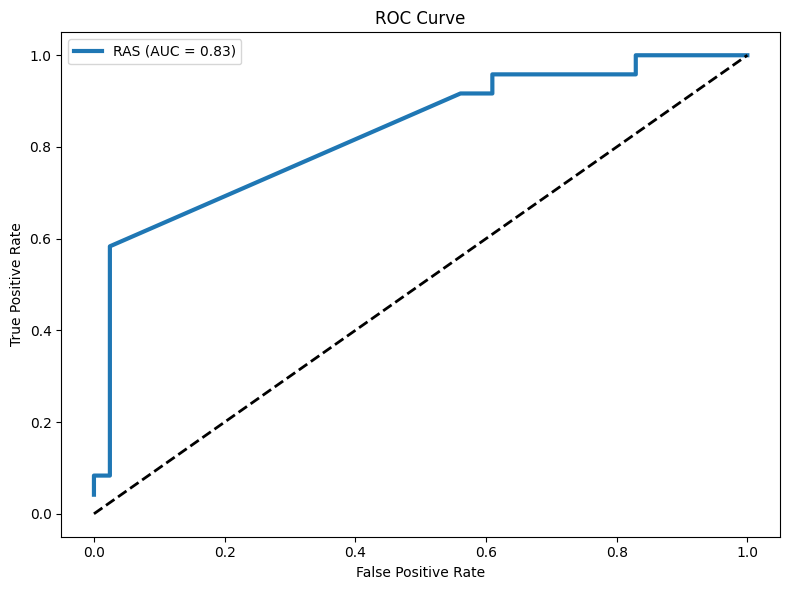


Training Elastic Net...
Best params for Elastic Net: {'model__C': 0.1, 'model__l1_ratio': 0.5}
Best CV ROC-AUC: 0.8199

Training Random Forest...
Best params for Random Forest: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
Best CV ROC-AUC: 0.8845

Training GBM...
Best params for GBM: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.8131

Training Decision Tree...
Best params for Decision Tree: {'model__max_depth': None, 'model__min_samples_leaf': 2}
Best CV ROC-AUC: 0.7756

Training FDA...
Best params for FDA: {'model__reg_param': 0.5}
Best CV ROC-AUC: 0.7009

Training KNN...
Best params for KNN: {'model__n_neighbors': 5, 'model__weights': 'distance'}
Best CV ROC-AUC: 0.8140

Training Logistic Regression...
Best params for Logistic Regression: {'model__C': 0.01}
Best CV ROC-AUC: 0.7482

Training Naive Bayesian...
Best params for Naive Bayesian: {'model__var_smoothing': 1e-08}
Best CV ROC-AUC: 0.

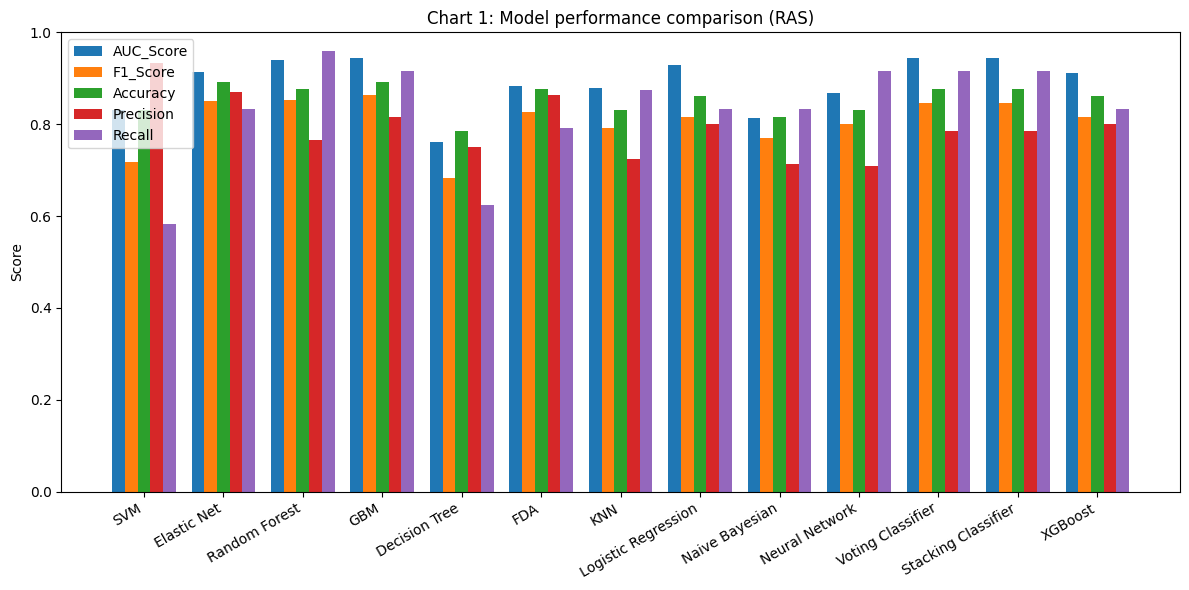

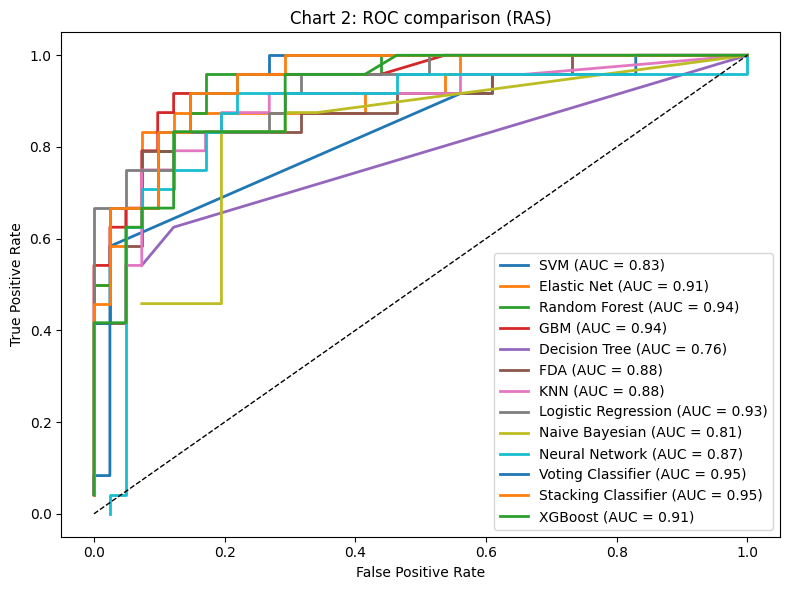


=== SVM: Learning curve ===


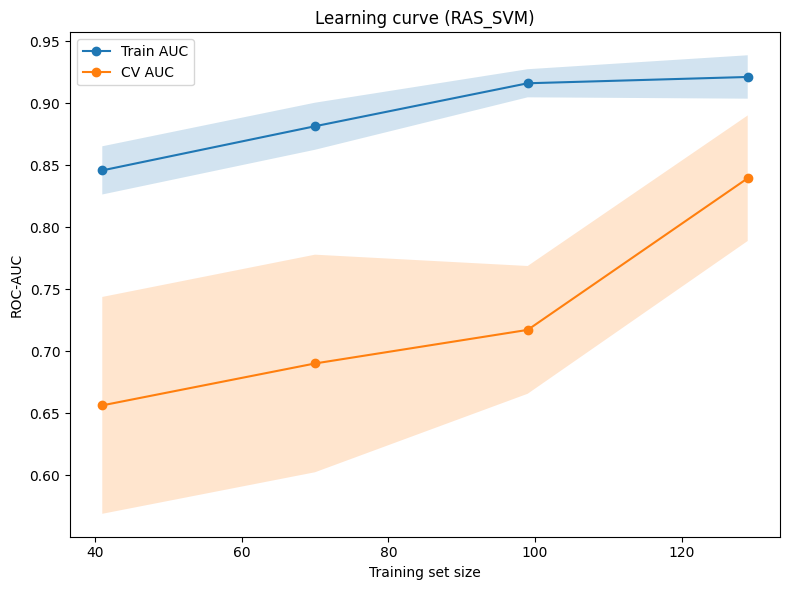


=== SVM: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

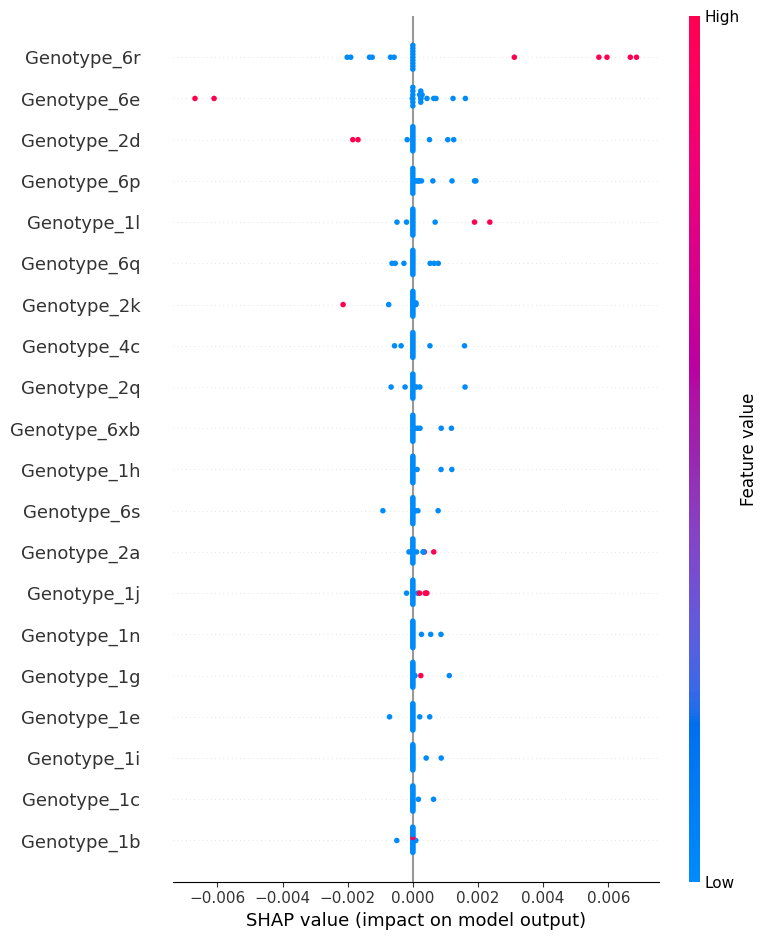

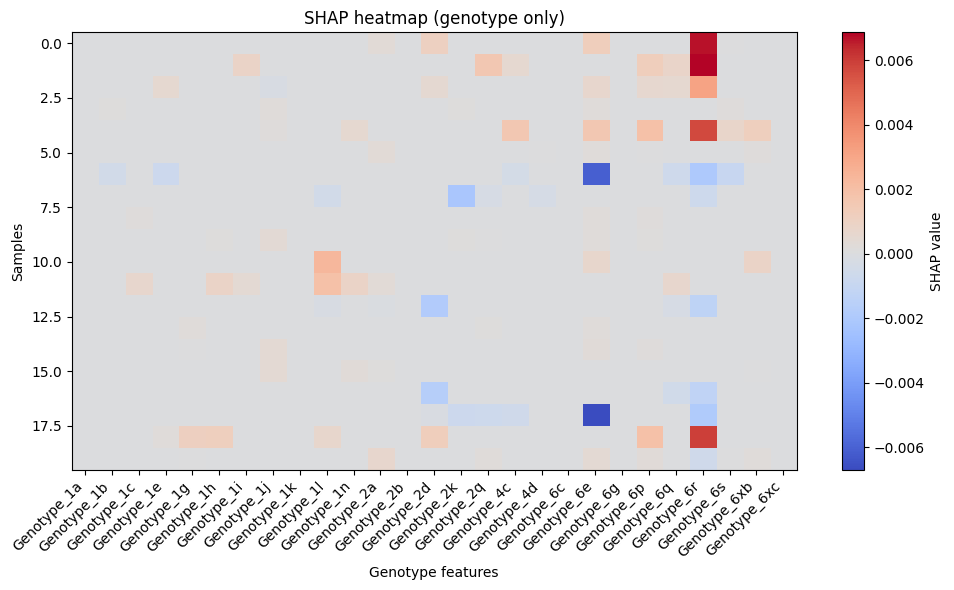


=== Elastic Net: Learning curve ===


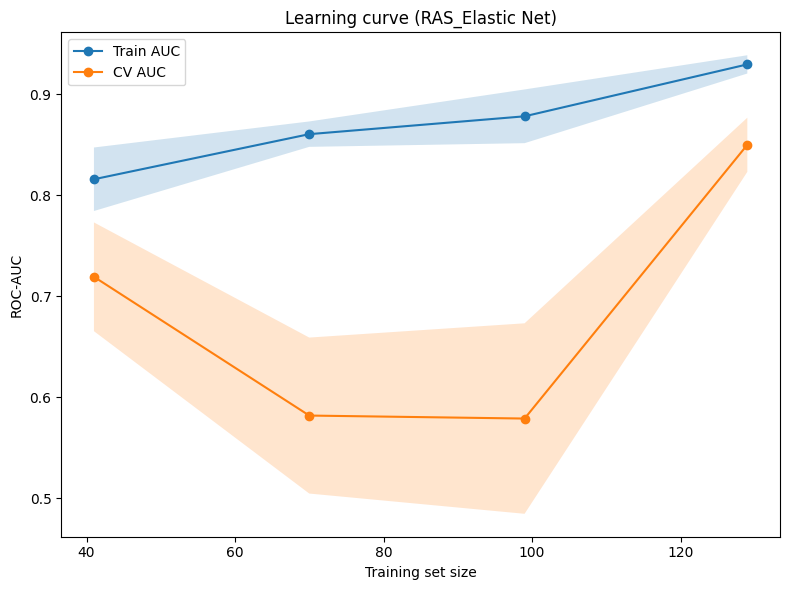


=== Elastic Net: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

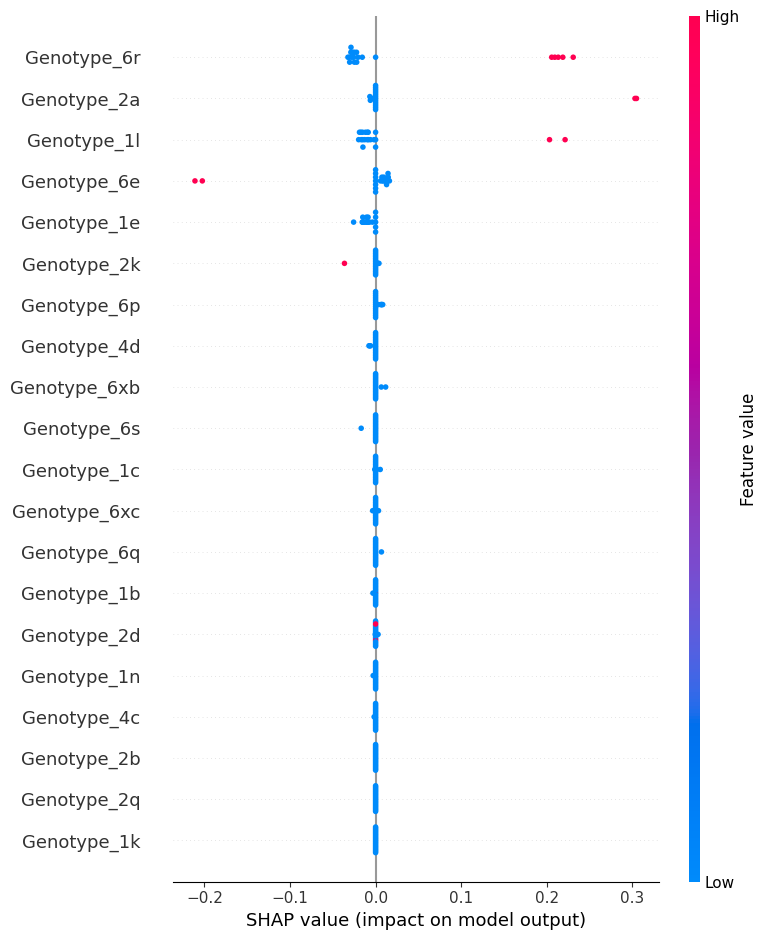

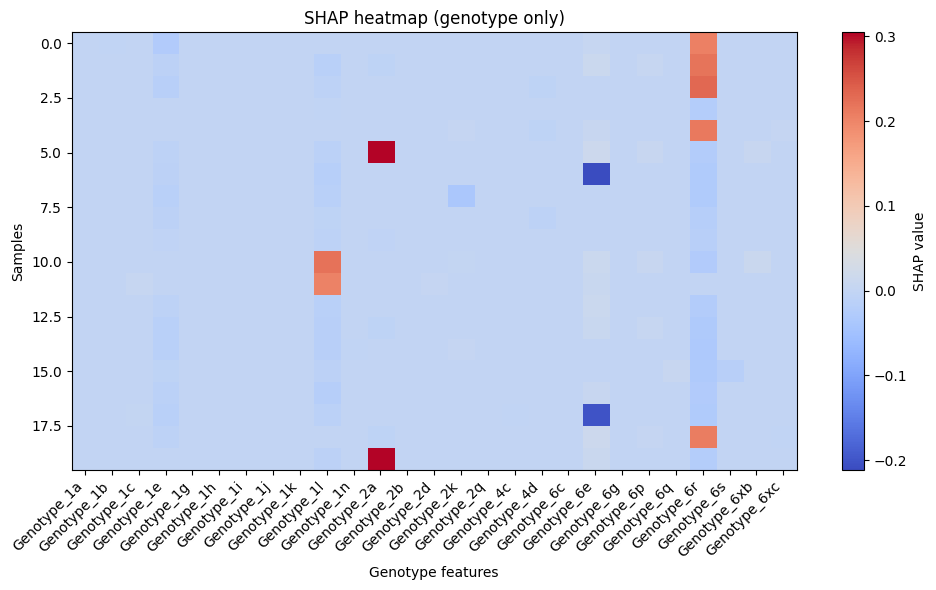


=== Random Forest: Learning curve ===


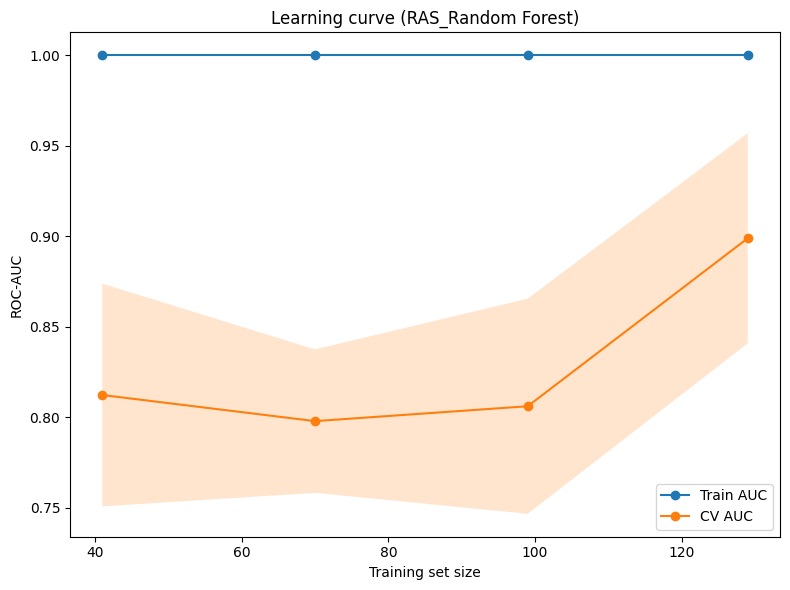


=== Random Forest: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

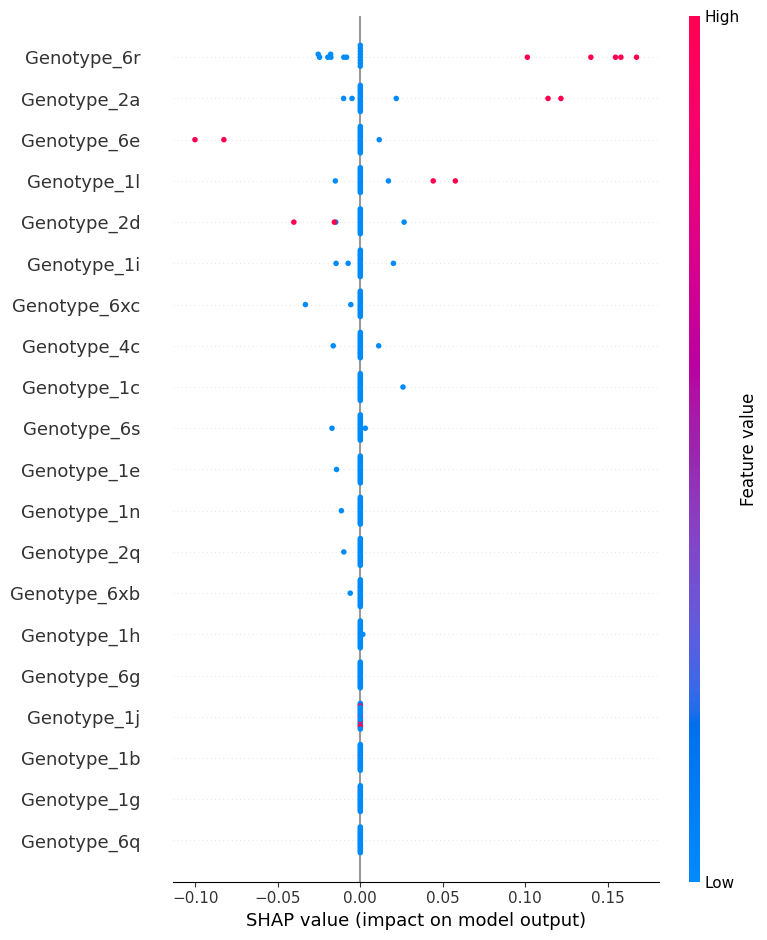

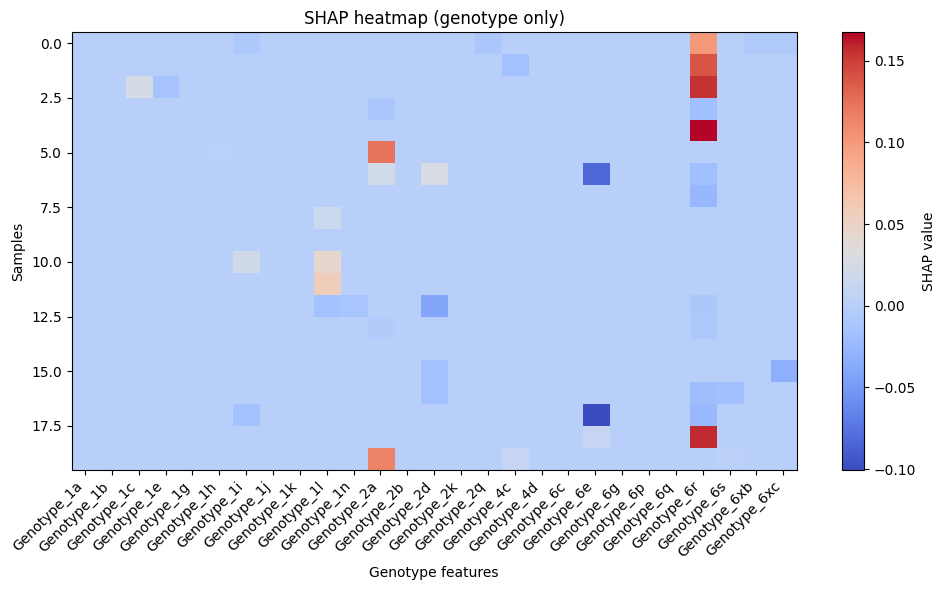


=== GBM: Learning curve ===


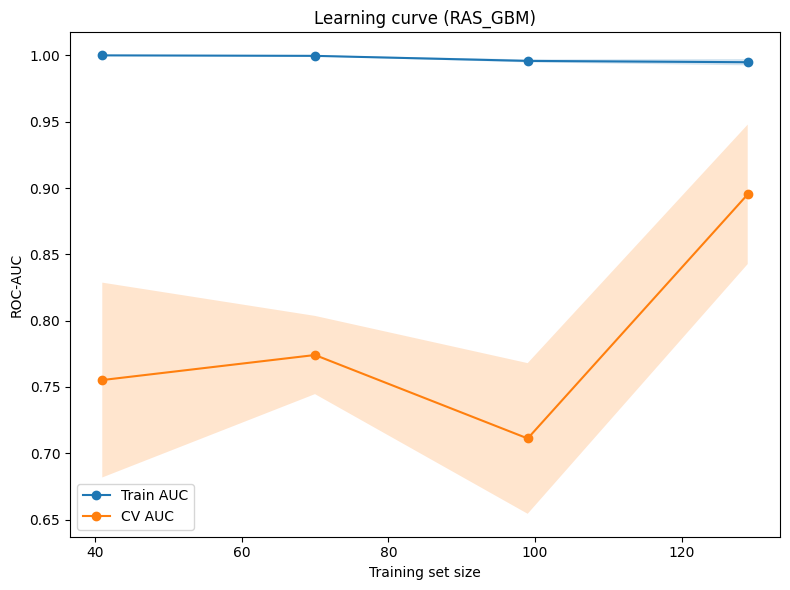


=== GBM: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

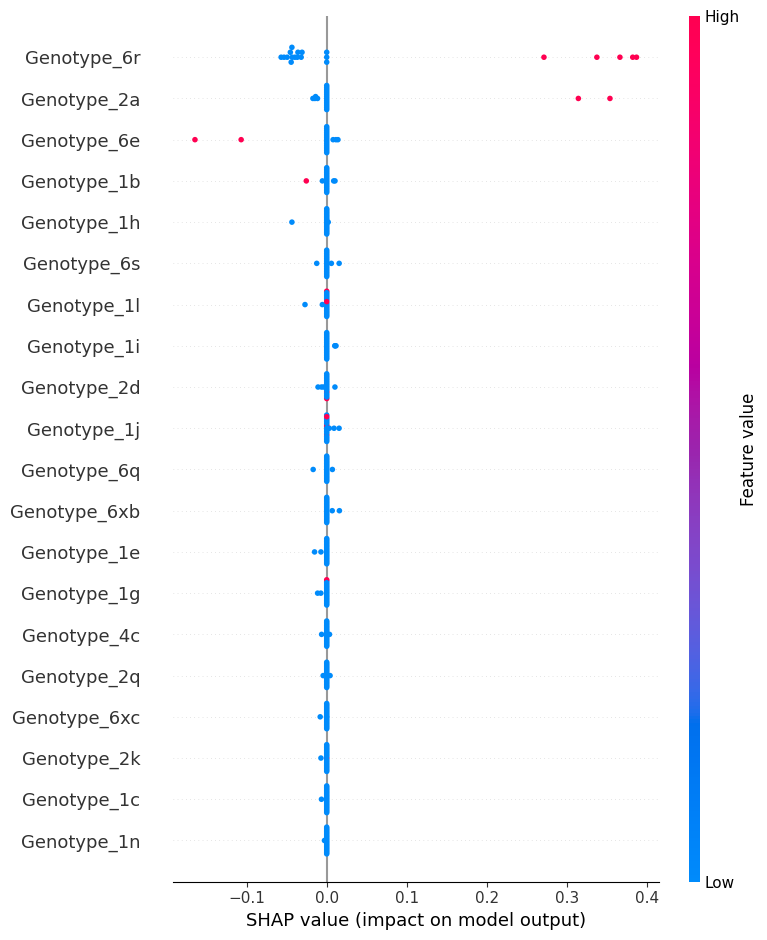

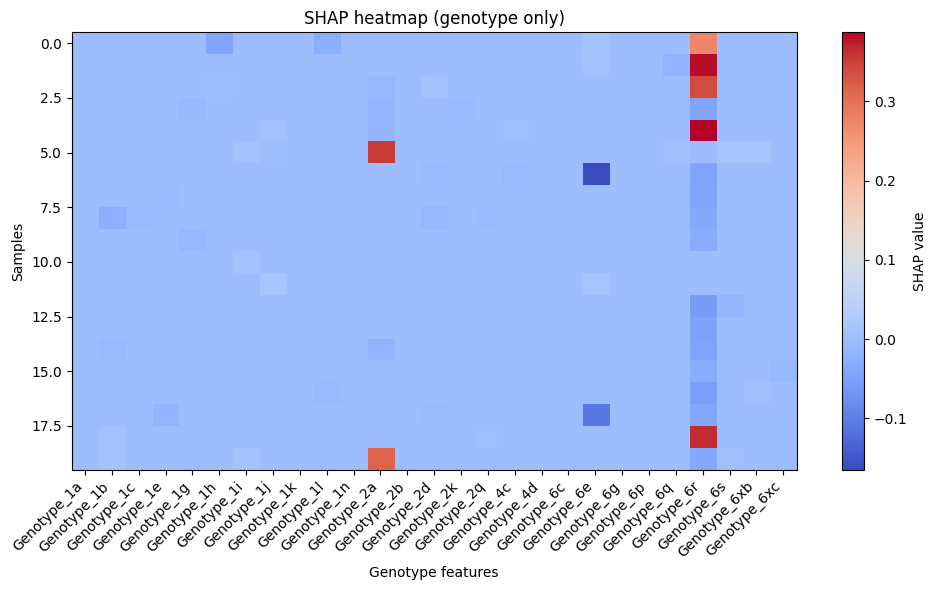


=== Decision Tree: Learning curve ===


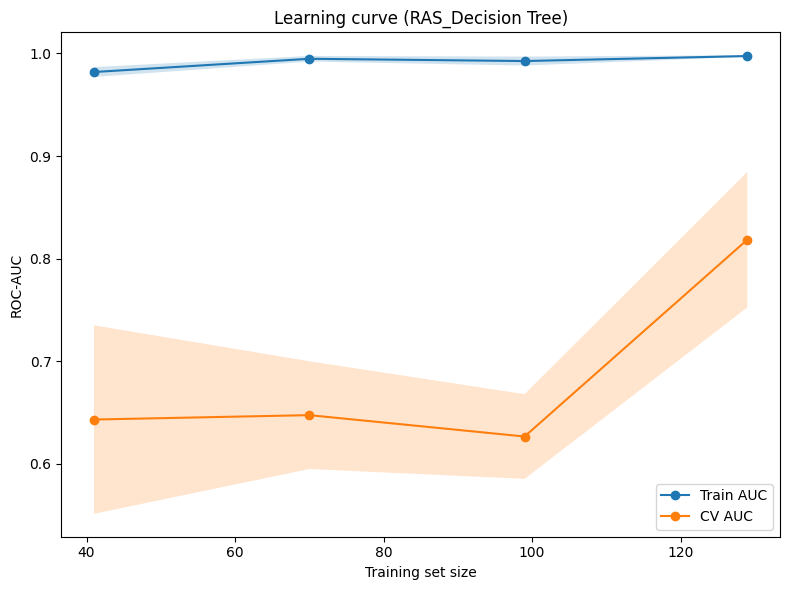


=== Decision Tree: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

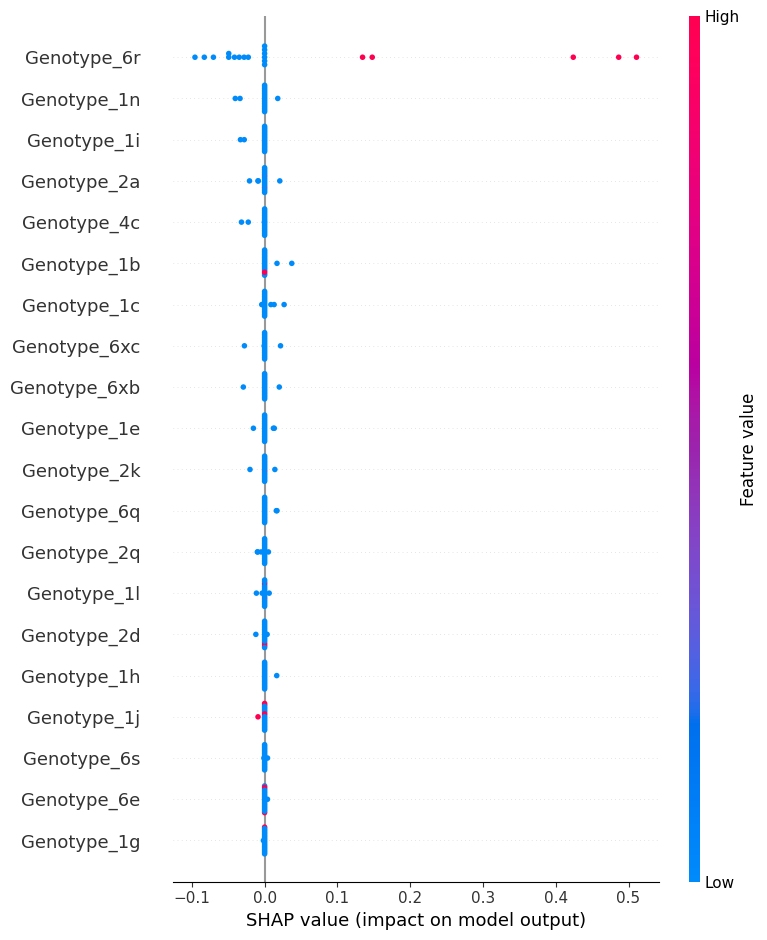

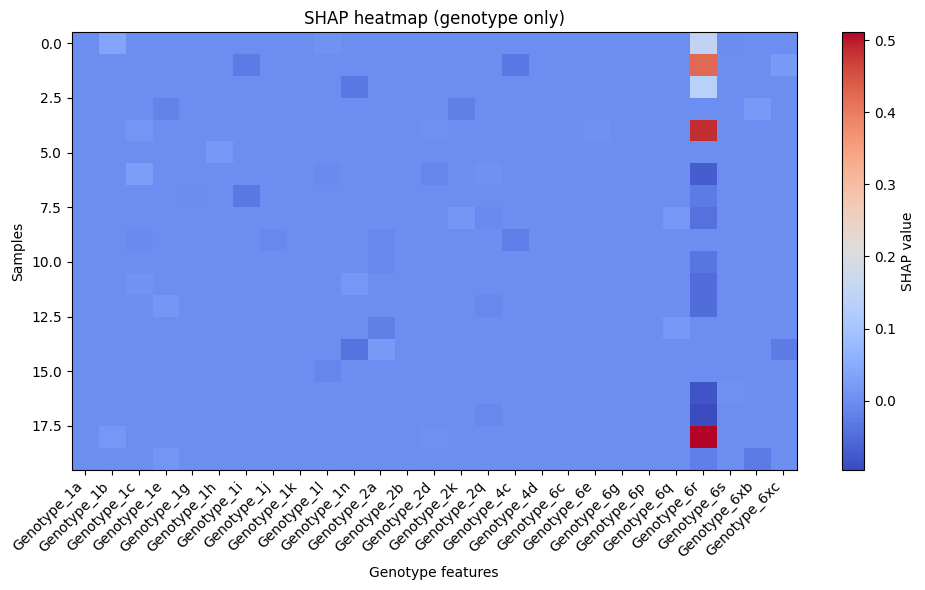


=== FDA: Learning curve ===


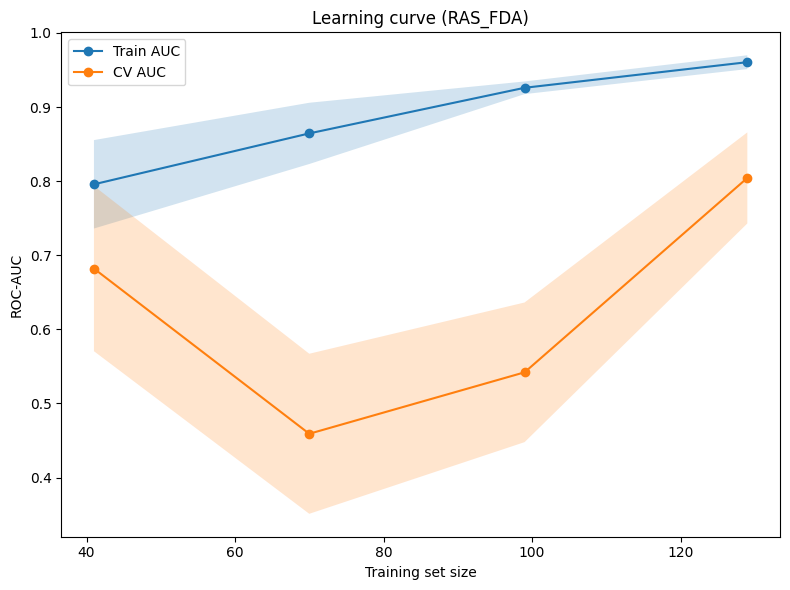


=== FDA: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

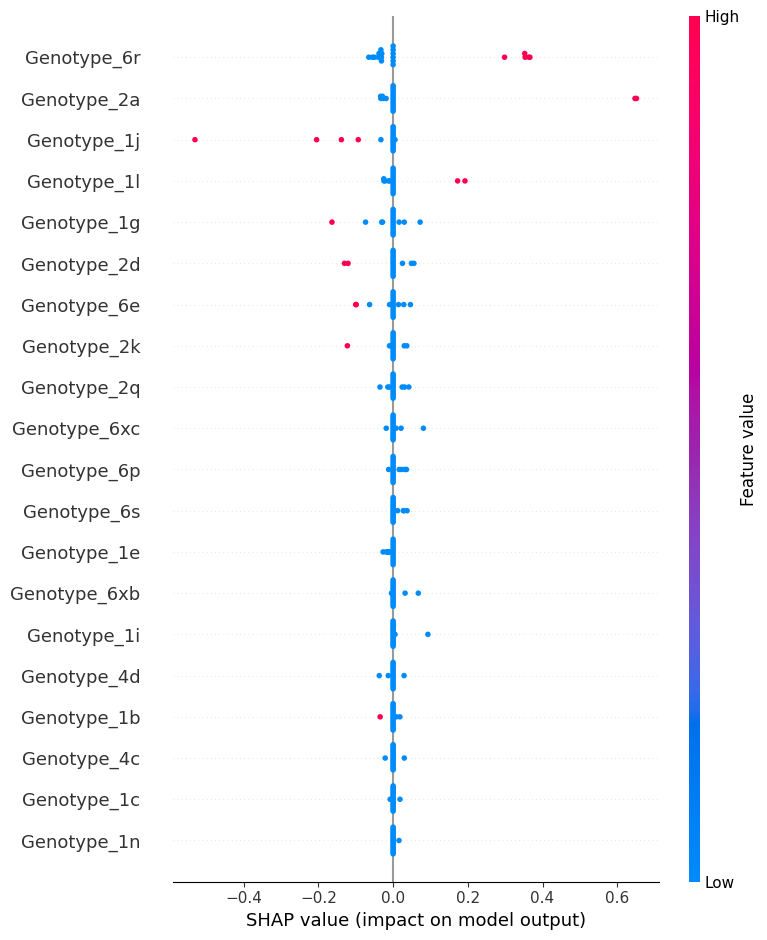

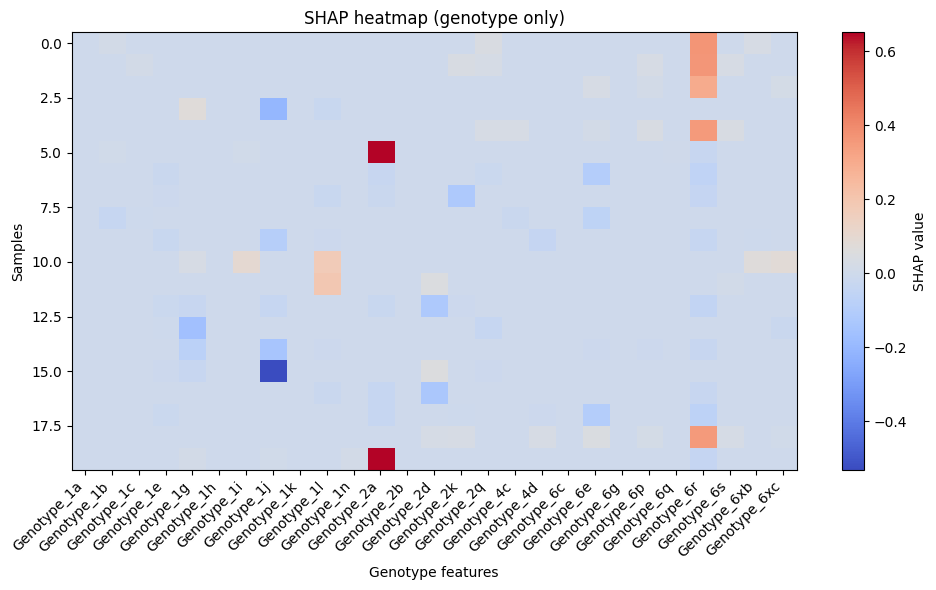


=== KNN: Learning curve ===


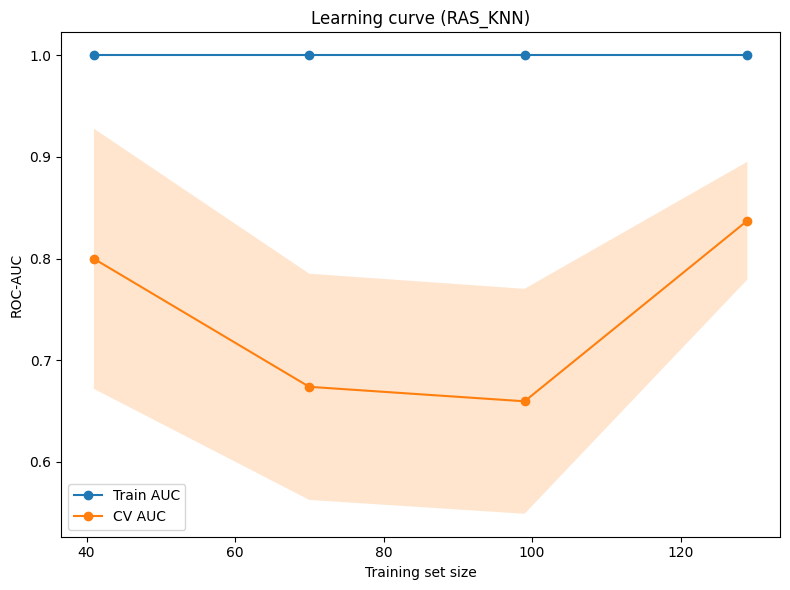


=== KNN: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

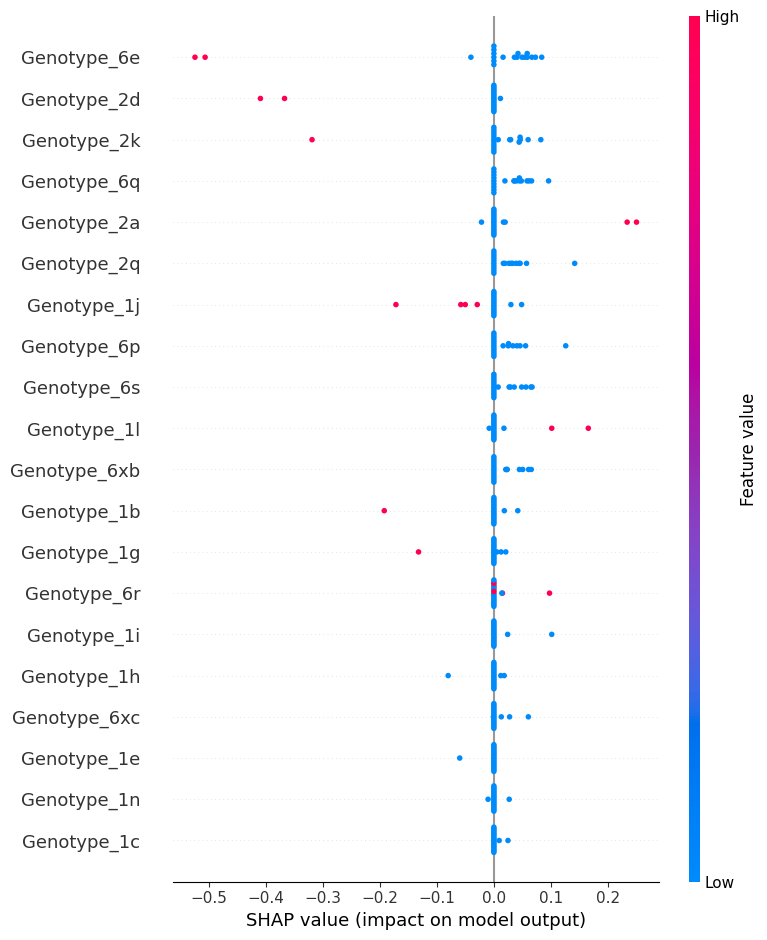

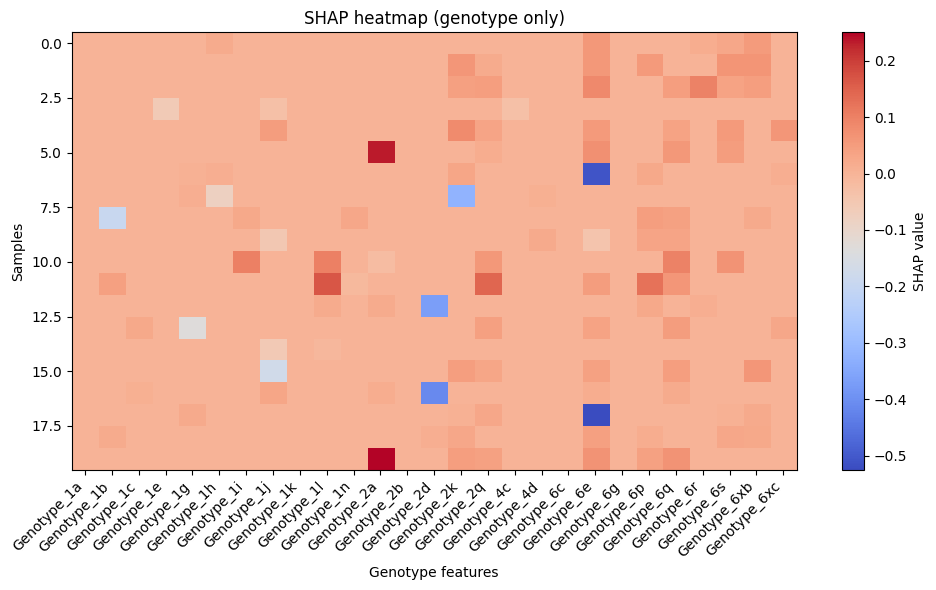


=== Logistic Regression: Learning curve ===


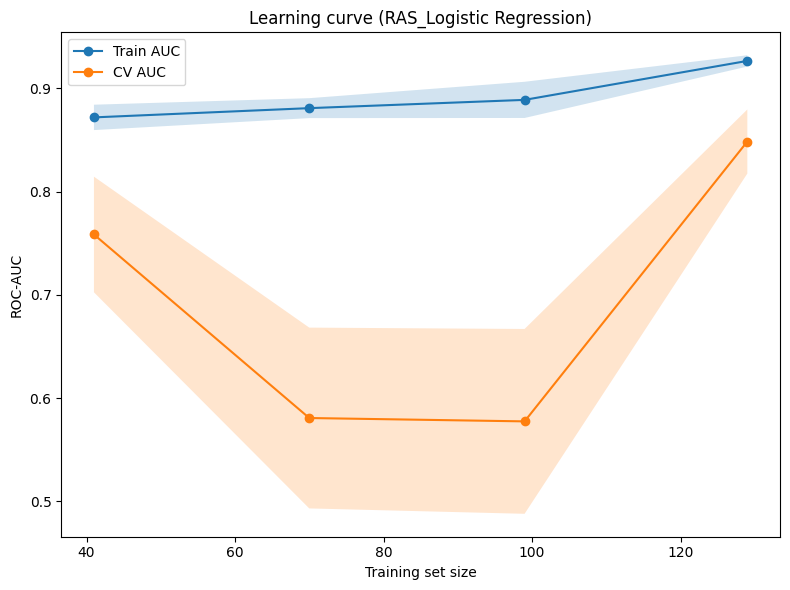


=== Logistic Regression: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

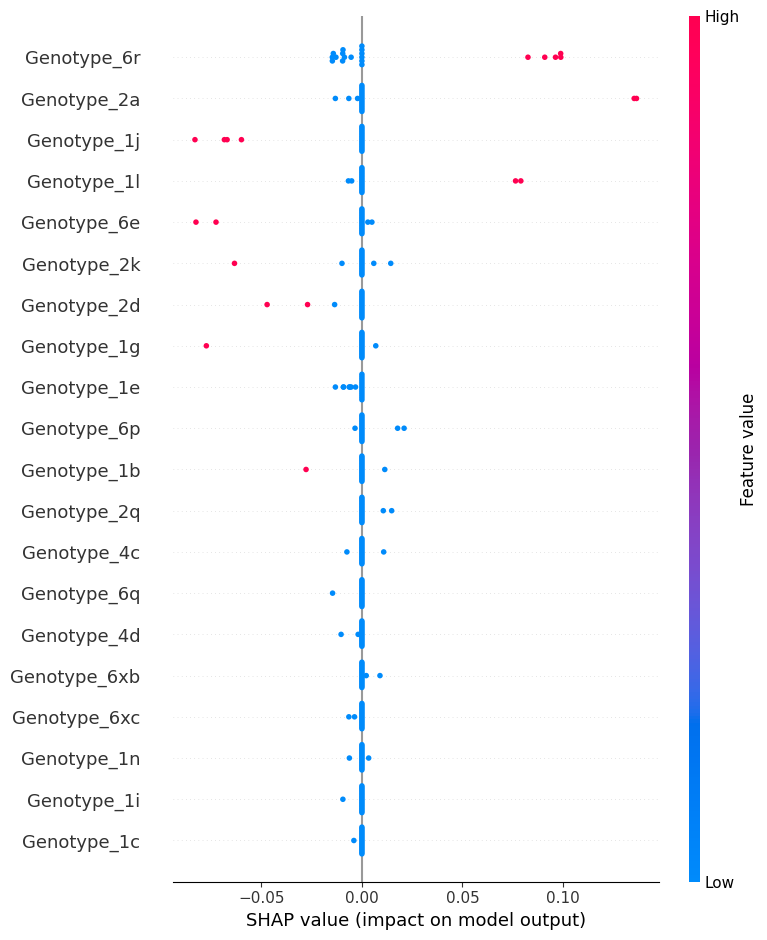

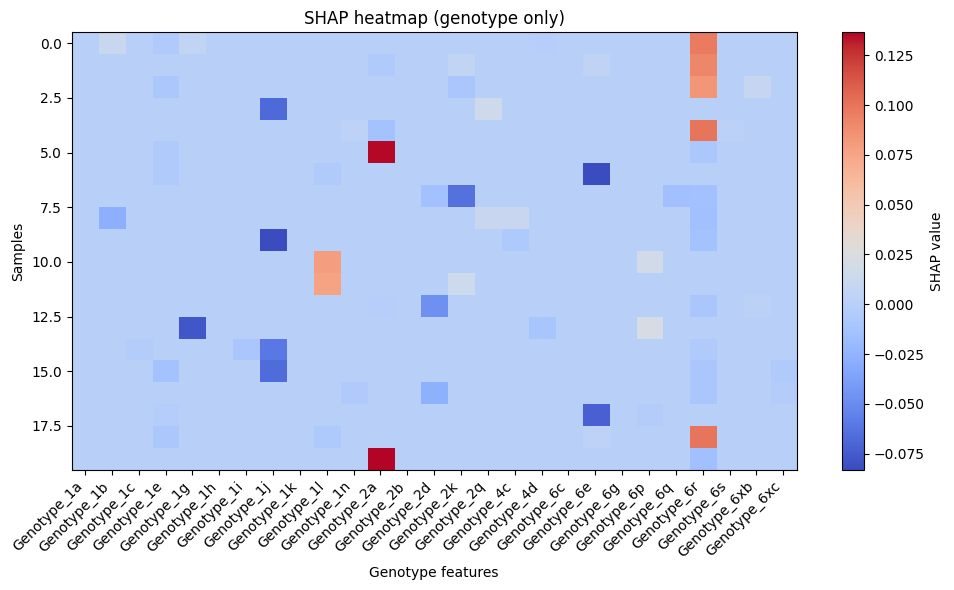


=== Naive Bayesian: Learning curve ===


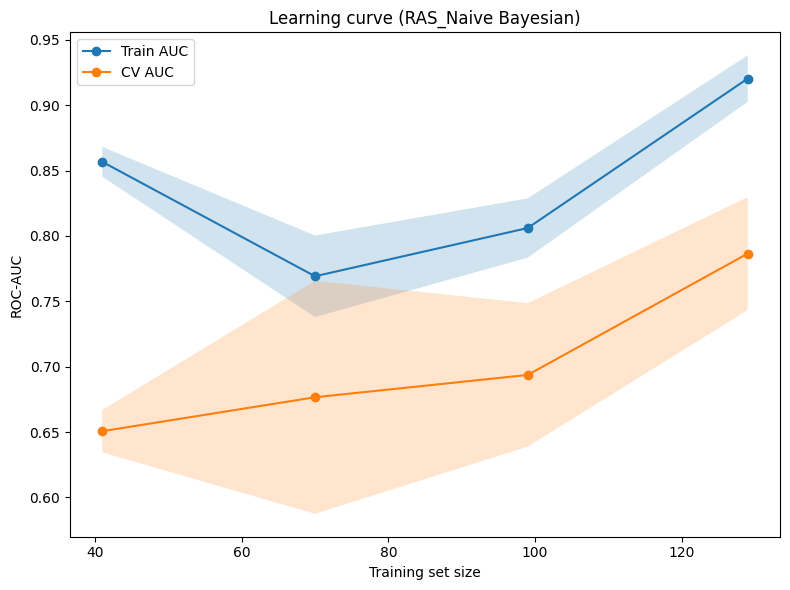


=== Naive Bayesian: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

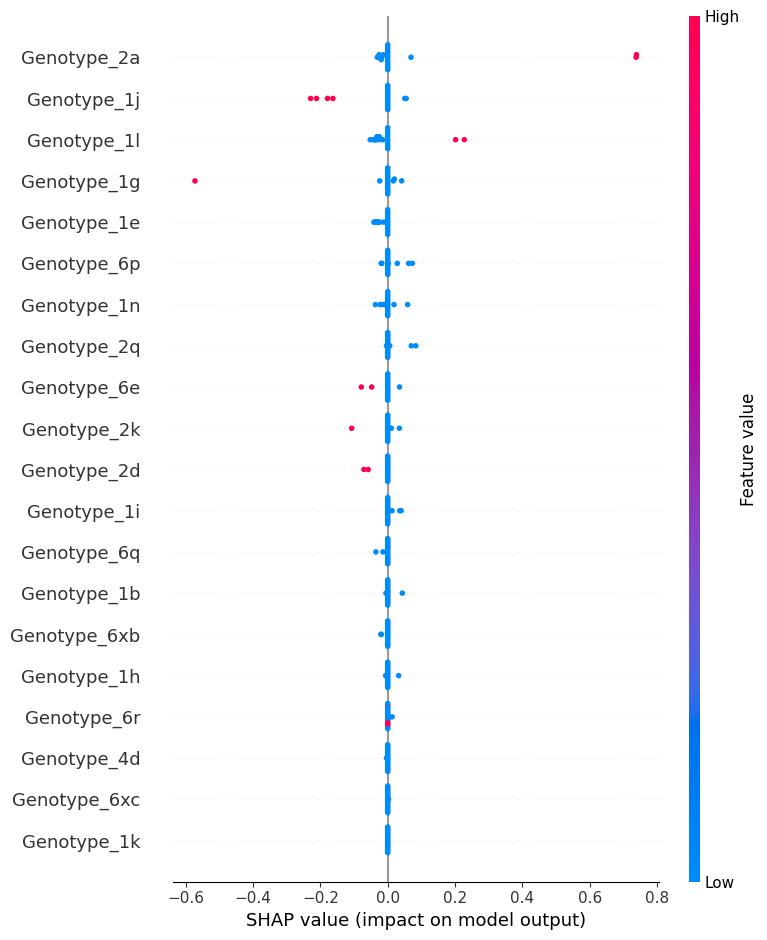

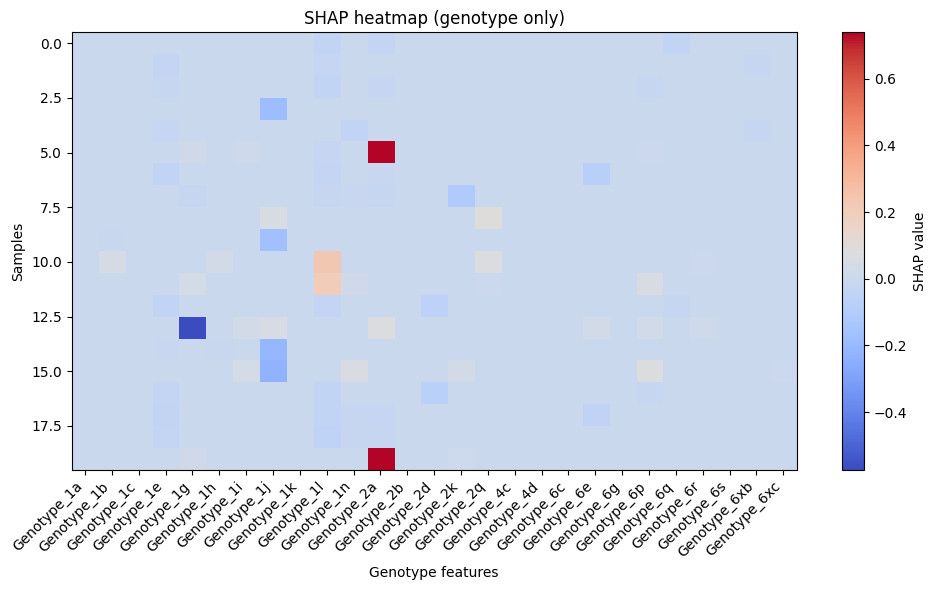


=== Neural Network: Learning curve ===


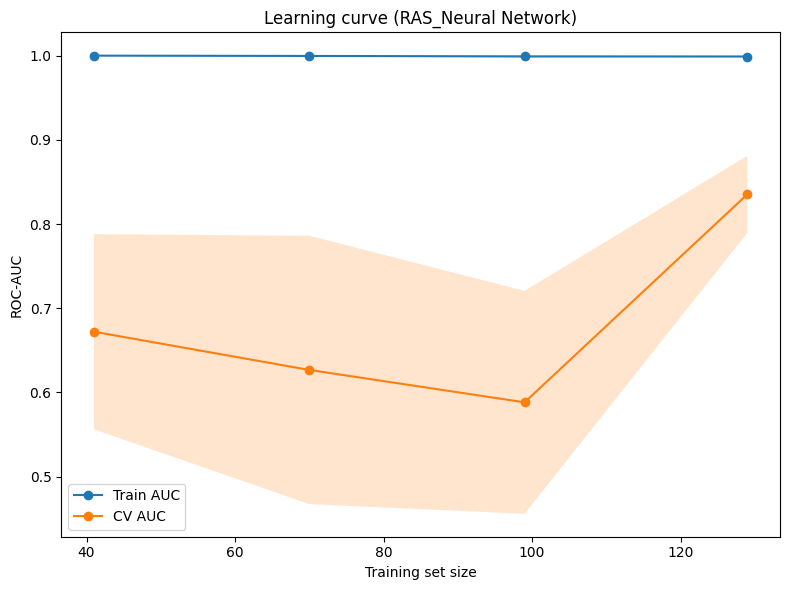


=== Neural Network: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

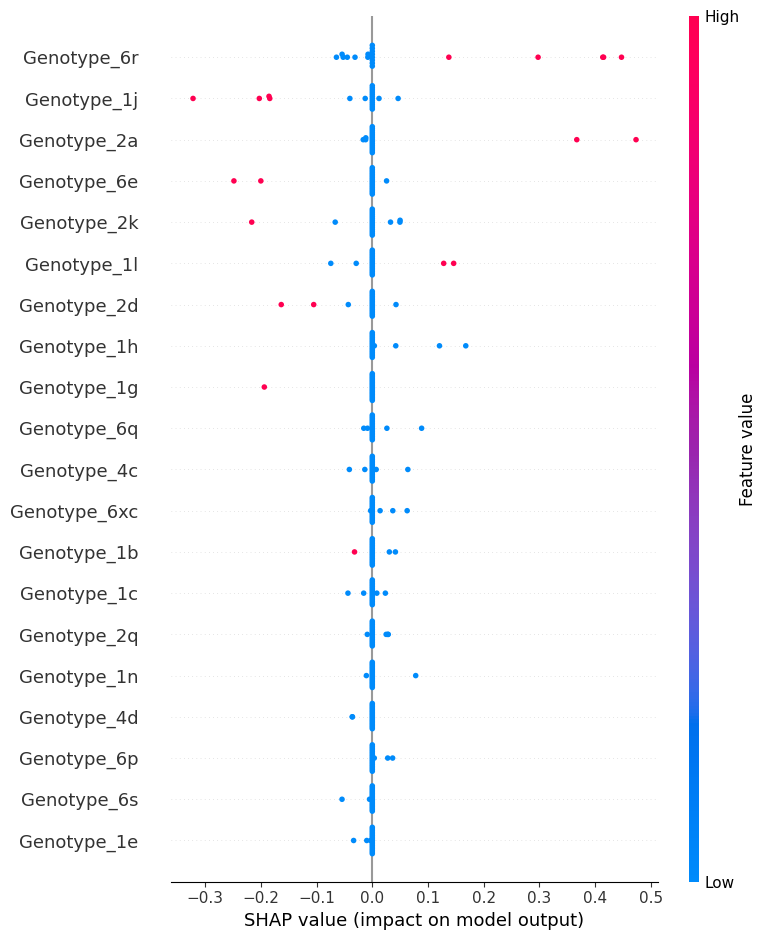

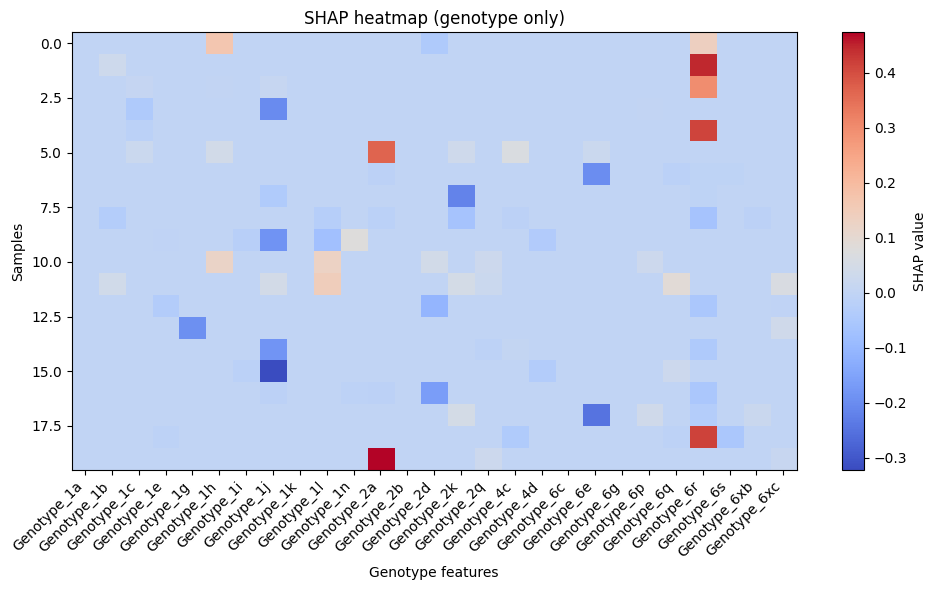


=== Voting Classifier: Learning curve ===


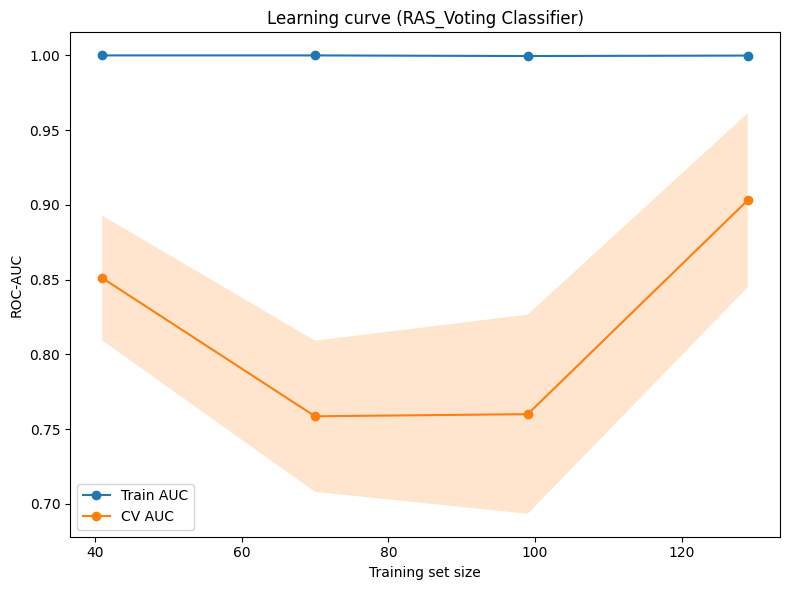


=== Voting Classifier: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

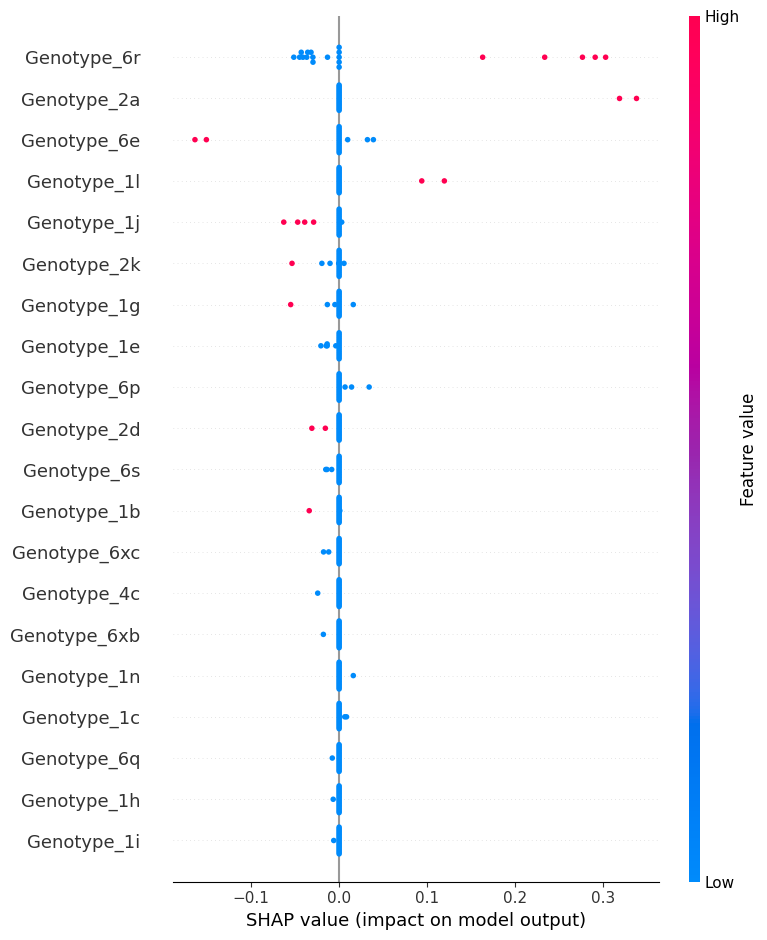

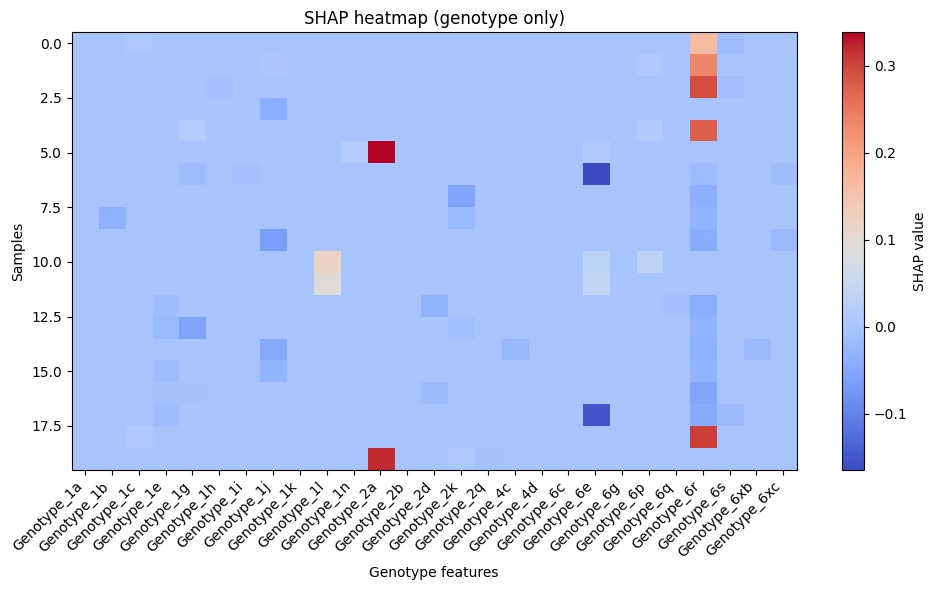


=== Stacking Classifier: Learning curve ===


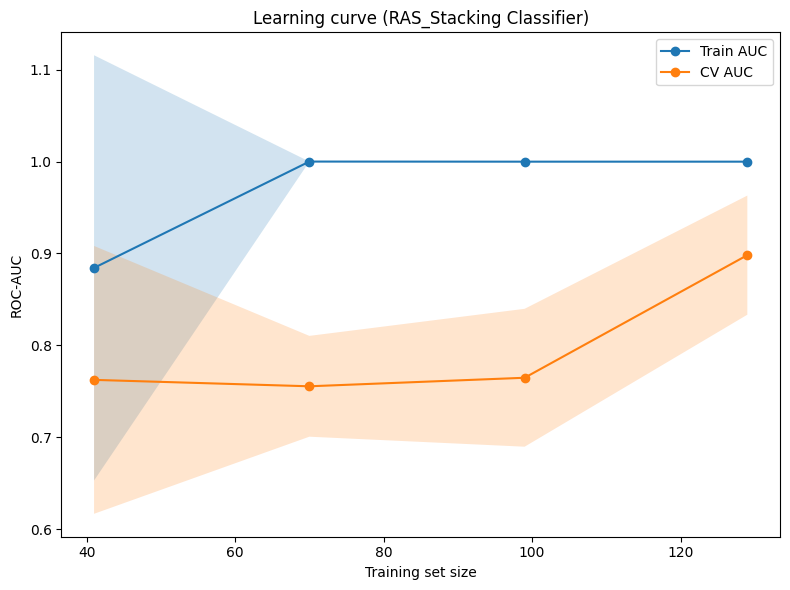


=== Stacking Classifier: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

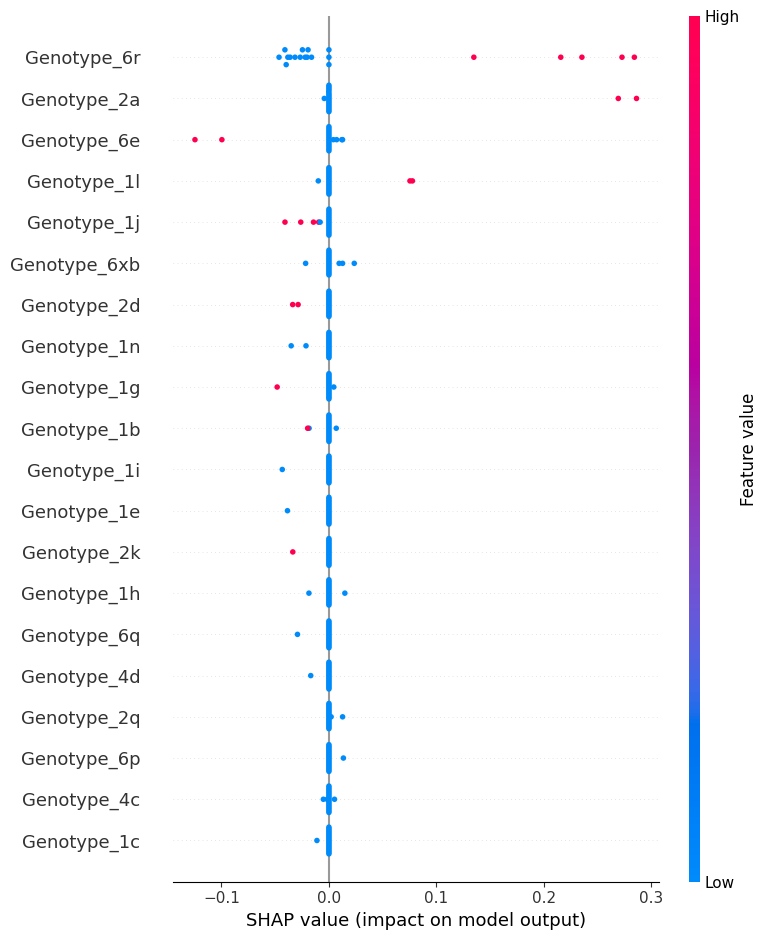

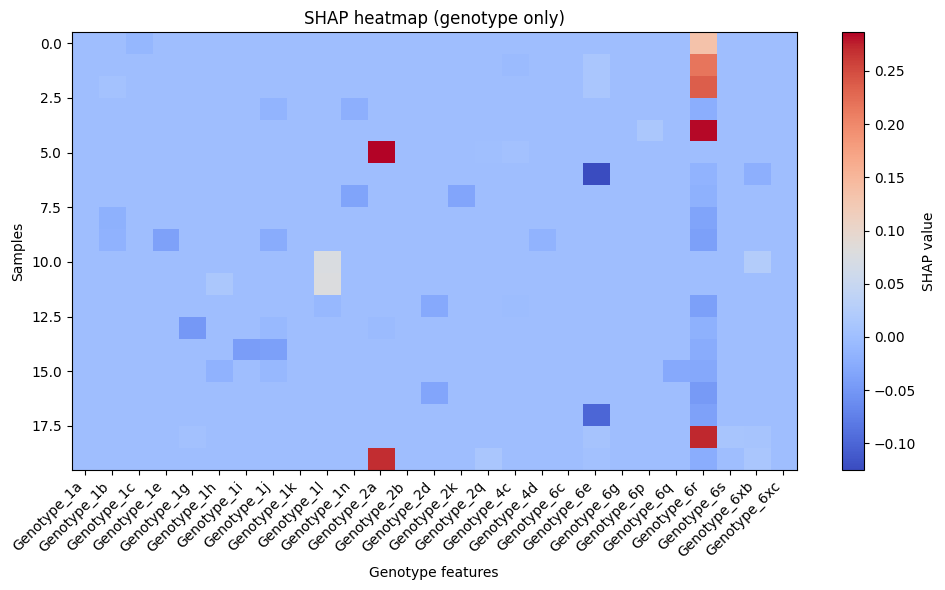


=== XGBoost: Learning curve ===


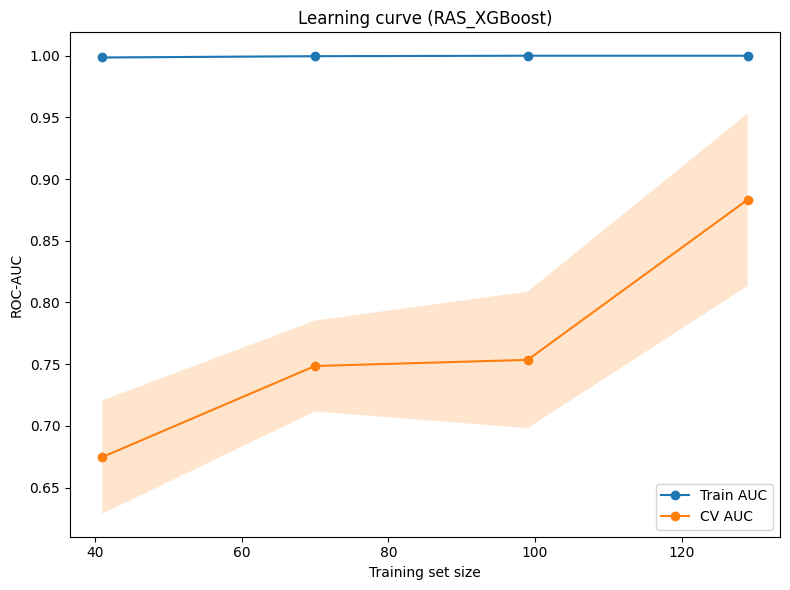


=== XGBoost: SHAP ===
Running SHAP on a small sample for explainability...


  0%|          | 0/20 [00:00<?, ?it/s]

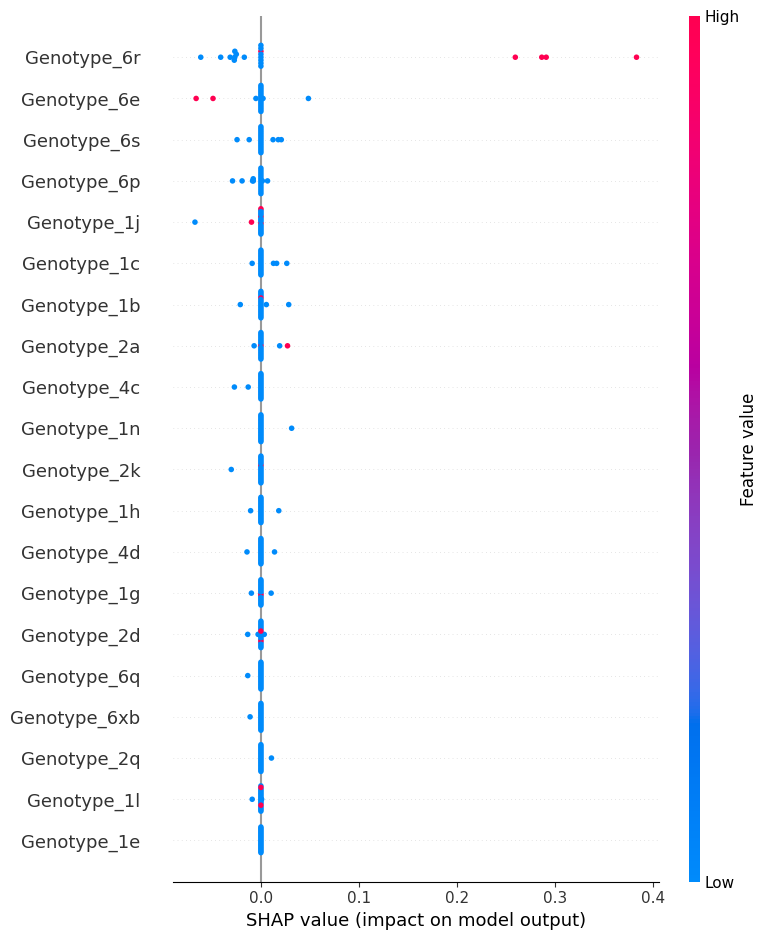

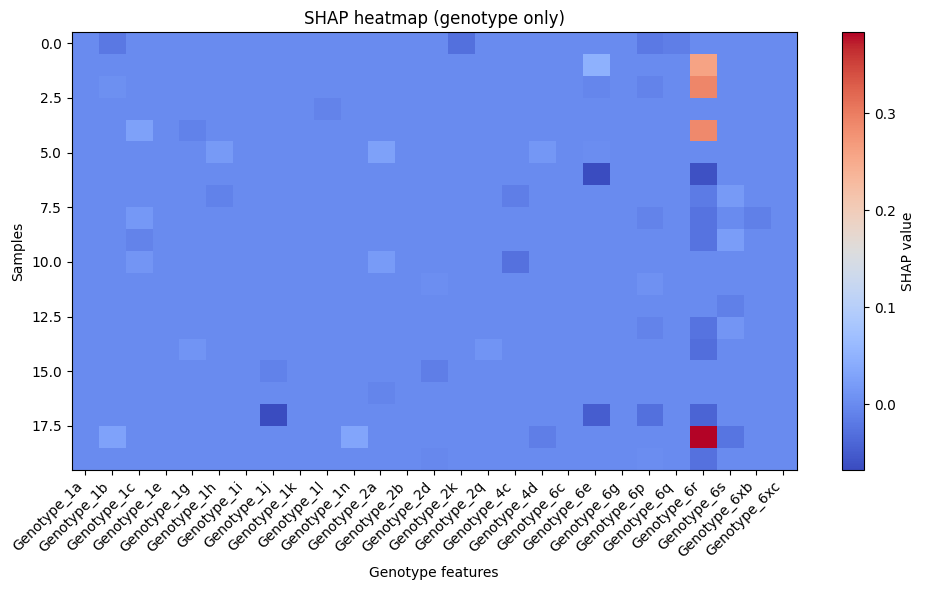


=== Bootstrap Sensitivity Analysis (RAS) ===

=== Bootstrap Sensitivity Analysis: SVM ===
    Iterations: 1000  |  Skipped: 0
    Accuracy      mean=0.8211  std=0.0624  95% CI=[0.6462, 0.9077]
    Precision     mean=0.9055  std=0.1220  95% CI=[0.4997, 1.0000]
    Recall        mean=0.6169  std=0.1303  95% CI=[0.4167, 0.9644]
    F1_Score      mean=0.7167  std=0.0772  95% CI=[0.5599, 0.8571]
    AUC_Score     mean=0.8280  std=0.0509  95% CI=[0.7270, 0.9161]

=== Bootstrap Sensitivity Analysis: Elastic Net ===
    Iterations: 1000  |  Skipped: 0
    Accuracy      mean=0.8942  std=0.0403  95% CI=[0.8154, 0.9692]
    Precision     mean=0.8578  std=0.0787  95% CI=[0.6842, 1.0000]
    Recall        mean=0.8612  std=0.0743  95% CI=[0.7037, 1.0000]
    F1_Score      mean=0.8559  std=0.0560  95% CI=[0.7346, 0.9546]
    AUC_Score     mean=0.9122  std=0.0408  95% CI=[0.8219, 0.9799]

=== Bootstrap Sensitivity Analysis: Random Forest ===
    Iterations: 1000  |  Skipped: 0
    Accuracy      mean=

In [11]:
ras_path = "data/data_RAS.xlsx"

run_dir = os.path.join("outputs", "Experiment_Model_" + datetime.now().strftime("%Y%m%d_%H%M%S"))

ras_significance = analyze_ras_significance(ras_path)

X, y, ras_df, ras_features, feature_names = build_feature_matrix(
    ras_path,
    ras_sheet="Sheet1",
)

results = train_and_evaluate_models(
    X,
    y,
    seq_df=ras_df,
    feature_names=feature_names,
    label="RAS",
    save_path=run_dir,
)

plot_model_comparisons(
    results,
    label="RAS",
    save_path=run_dir,
)

# Apply learning curves + SHAP to all trained models.
# Note: learning curves refit models (can be slow); SHAP KernelExplainer can also be expensive.
models_to_analyze = None  # e.g. ["SVM", "GBM"] to limit
for model_name, model_info in (results.get("models") or {}).items():
    if models_to_analyze is not None and model_name not in models_to_analyze:
        continue

    model_obj = (model_info or {}).get("model")
    if model_obj is None:
        print(f"{model_name}: model unavailable; skipping.")
        continue

    print(f"\n=== {model_name}: Learning curve ===")
    plot_learning_curve(
        model_obj,
        X,
        y,
        label=f"RAS_{model_name}",
        save_path=run_dir,
    )

    print(f"\n=== {model_name}: SHAP ===")
    explain_with_shap(
        model_obj,
        results["X_train"],
        results["X_test"],
        feature_names=results["feature_names"],
        save_path=run_dir,
        label=f"RAS_{model_name}",
    )

# --- Bootstrap Sensitivity Analysis (RAS) ---
print("\n=== Bootstrap Sensitivity Analysis (RAS) ===")
bootstrap_sensitivity_analysis(
    results,
    n_bootstraps=1000,
    label="RAS",
    save_path=run_dir,
)


In [ ]:
def plot_tsne_embedding(
    X,
    labels=None,
    text_labels=None,
    label_name="subtype",
    perplexity=None,
    max_iter=1000,
    pca_components=50,
    random_state=42,
    annotate=True,
    annotate_max_points=300,
    annotate_fontsize=8,
    draw_group_outline=False,
    outline_kind="ellipse",
    outline_n_std=2.0,
    outline_expand=1.15,
    outline_linewidth=2.0,
    outline_alpha=1.0,
    outline_min_points=3,
    circle_quantile=0.9,
    point_size=70,
    point_alpha=0.85,
    save_path=None,
    label="",
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle, Ellipse
    import seaborn as sns
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler

    X = np.asarray(X)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array of shape (n_samples, n_features).")

    n_samples = X.shape[0]
    if n_samples < 3:
        raise ValueError("t-SNE requires at least 3 samples.")

    labels_series = None
    if labels is not None:
        labels_series = pd.Series(labels).astype(str)
        if len(labels_series) != n_samples:
            raise ValueError("labels must have the same length as X.")

    text_series = None
    if text_labels is not None:
        text_series = pd.Series(text_labels).astype(str)
        if len(text_series) != n_samples:
            raise ValueError("text_labels must have the same length as X.")
    elif labels_series is not None:
        text_series = labels_series

    X_scaled = StandardScaler().fit_transform(X)
    X_for_tsne = X_scaled
    if pca_components and X_scaled.shape[1] > pca_components:
        n_comp = int(min(pca_components, X_scaled.shape[0] - 1, X_scaled.shape[1]))
        if n_comp >= 2:
            X_for_tsne = PCA(n_components=n_comp, random_state=random_state).fit_transform(X_scaled)

    if perplexity is None:
        perplexity = min(30, max(5, (n_samples - 1) // 3))
    perplexity = float(min(perplexity, n_samples - 1))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        max_iter=max_iter,
        random_state=random_state,
    )
    emb = tsne.fit_transform(X_for_tsne)

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 8))

    if labels_series is None:
        ax.scatter(
            emb[:, 0],
            emb[:, 1],
            s=point_size,
            alpha=point_alpha,
            color=sns.color_palette("deep", 1)[0],
            edgecolors="white",
            linewidths=0.5,
        )
    else:
        groups = list(pd.unique(labels_series))
        palette = sns.color_palette("Set1", n_colors=len(groups))
        color_map = dict(zip(groups, palette))
        for g in groups:
            mask = labels_series == g
            ax.scatter(
                emb[mask.values, 0],
                emb[mask.values, 1],
                s=point_size,
                alpha=point_alpha,
                color=color_map[g],
                label=g,
                edgecolors="white",
                linewidths=0.5,
            )

        if draw_group_outline:
            for g in groups:
                mask = labels_series == g
                pts = emb[mask.values]
                if pts.shape[0] < outline_min_points:
                    continue

                color = color_map.get(g, "black")
                center = pts.mean(axis=0)

                if str(outline_kind).lower() == "circle":
                    d = np.sqrt(((pts - center) ** 2).sum(axis=1))
                    radius = float(np.quantile(d, circle_quantile)) * float(outline_expand)
                    if np.isfinite(radius) and radius > 0:
                        ax.add_patch(
                            Circle(
                                xy=center,
                                radius=radius,
                                fill=False,
                                edgecolor=color,
                                linewidth=outline_linewidth,
                                alpha=outline_alpha,
                                zorder=0,
                            )
                        )
                else:
                    cov = np.cov(pts.T)
                    if not np.isfinite(cov).all():
                        continue
                    vals, vecs = np.linalg.eigh(cov)
                    order = np.argsort(vals)[::-1]
                    vals = vals[order]
                    vecs = vecs[:, order]
                    vals = np.maximum(vals, 1e-12)
                    width, height = 2.0 * float(outline_n_std) * np.sqrt(vals[:2])
                    width *= float(outline_expand)
                    height *= float(outline_expand)
                    angle = float(np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0])))
                    ax.add_patch(
                        Ellipse(
                            xy=center,
                            width=float(width),
                            height=float(height),
                            angle=angle,
                            fill=False,
                            edgecolor=color,
                            linewidth=outline_linewidth,
                            alpha=outline_alpha,
                            zorder=0,
                        )
                    )
        ax.legend(
            title=label_name,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=min(4, len(groups)),
            frameon=False,
        )

    if annotate and text_series is not None:
        if len(text_series) > annotate_max_points:
            print(
                f"Skipping point labels: n={len(text_series)} exceeds annotate_max_points={annotate_max_points}."
            )
        else:
            dx = 0.01 * (float(emb[:, 0].max()) - float(emb[:, 0].min()) or 1.0)
            dy = 0.01 * (float(emb[:, 1].max()) - float(emb[:, 1].min()) or 1.0)
            for i in range(n_samples):
                if labels_series is None:
                    txt_color = "black"
                else:
                    txt_color = color_map.get(labels_series.iloc[i], "black")
                ax.text(
                    emb[i, 0] + dx,
                    emb[i, 1] + dy,
                    text_series.iloc[i],
                    fontsize=annotate_fontsize,
                    color=txt_color,
                    alpha=0.9,
                )

    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    title = "Unsupervised clustering of training data using t-SNE dimensionality reduction."
    if label:
        title = f"{title} ({label})"
    ax.set_title(title)
    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        safe_label = (label or "run").replace(" ", "_")
        out_path = os.path.join(save_path, f"tsne_training_data_{safe_label}.png")
        plt.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()
    return emb

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis


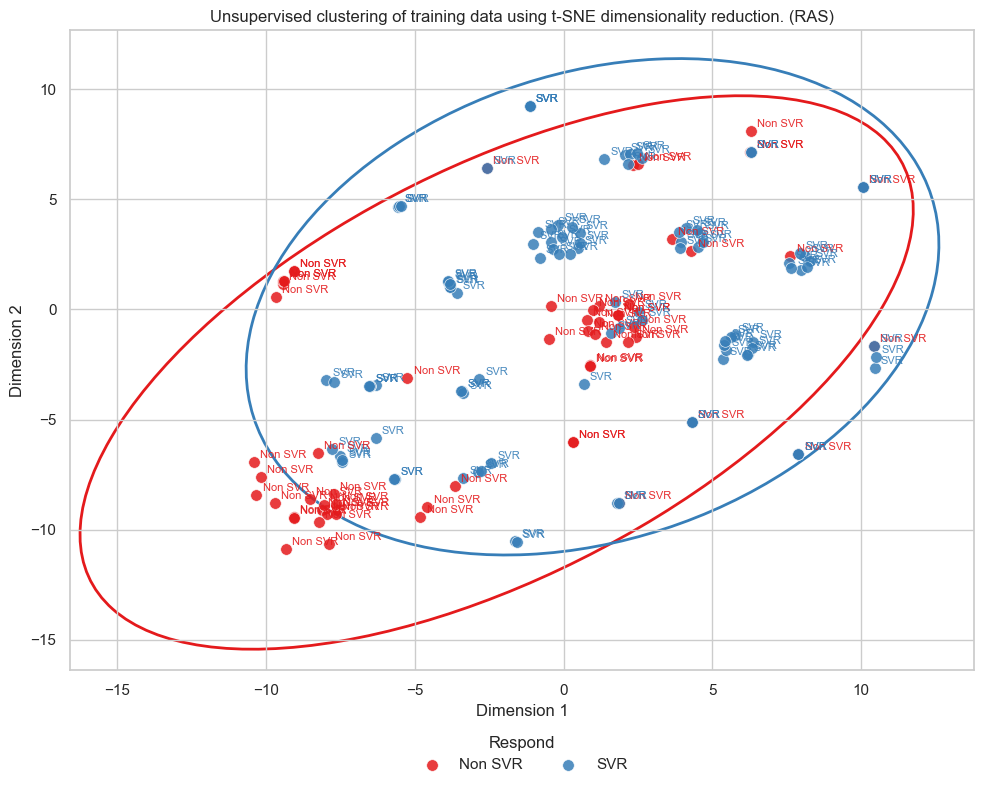

In [ ]:
# t-SNE visualization (unsupervised embedding, styled like the reference chart)
if "X" in globals() and "ras_df" in globals() and "run_dir" in globals():
    _ = plot_tsne_embedding(
        X,
        labels=ras_df["Respond"] if "Respond" in ras_df.columns else None,
        text_labels=ras_df["Respond"] if "Respond" in ras_df.columns else None,
        label_name="Respond",
        draw_group_outline=True,
        outline_kind="ellipse",
        save_path=run_dir,
        label="RAS",
    )
else:
    print("Run the training cell above first (to define X, ras_df, and run_dir).")
